# COMP47950 Quantum Machine Learning Project

Replication of Selig et al. [20] variational classifier on 2–3 datasets, with classical baseline and real-device inference.

## 1. Datasets and train/test split

We use three datasets from [20] Table 1, loaded via scikit-learn:

| Dataset | Features | Classes | Train | Test | Notes |
|---------|----------|---------|-------|------|-------|
| Iris | 4 | 3 | 90 | 60 | No PCA |
| Wine | 13 | 3 | 108 | 70 | PCA (8 or 12 PCs) in preprocessing |
| Breast Cancer Wisconsin | 32 | 2 | 449 | 120 | PCA (12 or 16 PCs) in preprocessing |

**Split strategy:** Stratified train/test split matching [20] sizes, with `random_state=42` for reproducibility. Data is loaded on-the-fly from sklearn (no local caching).

In [1]:
from qml_project.datasets import (
    load_iris_splits,
    load_wine_splits,
    load_breast_cancer_splits,
)

In [2]:
X_iris_tr, X_iris_te, y_iris_tr, y_iris_te = load_iris_splits()
X_wine_tr, X_wine_te, y_wine_tr, y_wine_te = load_wine_splits()
X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = load_breast_cancer_splits()

print("Iris:", X_iris_tr.shape, X_iris_te.shape)
print("Wine:", X_wine_tr.shape, X_wine_te.shape)
print("Breast Cancer:", X_bc_tr.shape, X_bc_te.shape)

Iris: (90, 4) (60, 4)
Wine: (108, 13) (70, 13)
Breast Cancer: (449, 30) (120, 30)


In [3]:
import numpy as np

for name, y_tr, y_te in [
    ("Iris", y_iris_tr, y_iris_te),
    ("Wine", y_wine_tr, y_wine_te),
    ("Breast Cancer", y_bc_tr, y_bc_te),
]:
    tr_counts = np.bincount(y_tr)
    te_counts = np.bincount(y_te)
    print(f"{name}: train {dict(zip(range(len(tr_counts)), tr_counts))}, test {dict(zip(range(len(te_counts)), te_counts))}")

Iris: train {0: np.int64(30), 1: np.int64(30), 2: np.int64(30)}, test {0: np.int64(20), 1: np.int64(20), 2: np.int64(20)}
Wine: train {0: np.int64(36), 1: np.int64(43), 2: np.int64(29)}, test {0: np.int64(23), 1: np.int64(28), 2: np.int64(19)}
Breast Cancer: train {0: np.int64(167), 1: np.int64(282)}, test {0: np.int64(45), 1: np.int64(75)}


## 2. Preprocessing

All datasets are centred and scaled using `StandardScaler` (fit on training data only; transform applied to both train and test splits). For Wine (13 raw features) and Breast Cancer (30 raw features), we additionally apply PCA to reduce dimensionality before encoding.

### Why PCA? Feature selection as a quantum constraint

In classical ML, high-dimensional feature spaces are routine — wider data simply requires more compute. For quantum methods, however, the number of features directly constrains circuit design: each feature must be encoded into one or more qubit rotations, so the feature count determines the minimum circuit width (number of qubits). On current NISQ hardware, circuits are limited to roughly 10–100 qubits with significant noise, making it impractical to encode all 13 (Wine) or 30 (Breast Cancer) raw features directly.

This is a concrete instance of the **input problem** — one of the four key challenges in QML identified by Biamonte et al. [1]: *representing classical data in a way appropriate for quantum devices is hard*. PCA addresses this by projecting the data onto a lower-dimensional subspace (8 components for Wine, 12 for Breast Cancer, following [20]) that retains most of the variance while fitting within the qubit budget.

**Fair comparison:** The same PCA-reduced features are used for both the classical baselines and the QML pipeline, ensuring that any performance differences reflect the models themselves rather than differences in the input feature space.

### Angle mapping ([20] Eq. 2)

After scaling (and optional PCA), features destined for the quantum circuit are transformed via [20]'s angle mapping:

$$f(x) = \frac{(1-\alpha^2)\pi}{q} \cdot W$$

with $\alpha = 0.1$ and $q = 3$. Here $W$ is the scaled (and optionally PCA-reduced) feature vector. This maps values into a rotation-friendly range, avoiding saturation at the poles of the Bloch sphere. The classical baselines skip this step (no angle mapping) since it is specific to the quantum encoding.

In [4]:
from qml_project.preprocessing import preprocess

# Iris: no PCA
X_iris_tr_cl, X_iris_te_cl, _ = preprocess(X_iris_tr, X_iris_te, apply_angle_mapping_flag=False)
X_iris_tr_qml, X_iris_te_qml, _ = preprocess(X_iris_tr, X_iris_te, apply_angle_mapping_flag=True)

# Wine: PCA 8 components
X_wine_tr_cl, X_wine_te_cl, _ = preprocess(X_wine_tr, X_wine_te, n_components=8, apply_angle_mapping_flag=False)
X_wine_tr_qml, X_wine_te_qml, _ = preprocess(X_wine_tr, X_wine_te, n_components=8, apply_angle_mapping_flag=True)

# Breast Cancer: PCA 12 components
X_bc_tr_cl, X_bc_te_cl, _ = preprocess(X_bc_tr, X_bc_te, n_components=12, apply_angle_mapping_flag=False)
X_bc_tr_qml, X_bc_te_qml, _ = preprocess(X_bc_tr, X_bc_te, n_components=12, apply_angle_mapping_flag=True)

print("Classical (scale+PCA): Iris", X_iris_tr_cl.shape, "Wine", X_wine_tr_cl.shape, "BC", X_bc_tr_cl.shape)

Classical (scale+PCA): Iris (90, 4) Wine (108, 8) BC (449, 12)


## 3. Classical ML baseline

We train three classical classifiers (Logistic Regression, Random Forest, SVM) on the preprocessed data (scale + PCA where applicable). 

**Data prep:** Same as above; no angle mapping.

**Sampling:** Fixed train/test split from §1.

**Metrics:** Accuracy, F1 (macro), precision (macro), recall (macro), and confusion matrix.

In [5]:
from qml_project.baselines import evaluate_baselines
import pandas as pd

results_iris = evaluate_baselines(X_iris_tr_cl, X_iris_te_cl, y_iris_tr, y_iris_te)
results_wine = evaluate_baselines(X_wine_tr_cl, X_wine_te_cl, y_wine_tr, y_wine_te)
results_bc = evaluate_baselines(X_bc_tr_cl, X_bc_te_cl, y_bc_tr, y_bc_te)

In [6]:
def metrics_table(results: dict, dataset: str) -> pd.DataFrame:
    rows = []
    for model, r in results.items():
        rows.append({
            "Model": model,
            "Dataset": dataset,
            "Accuracy": f"{r['accuracy']:.4f}",
            "F1 (macro)": f"{r['f1_macro']:.4f}",
            "Precision (macro)": f"{r['precision_macro']:.4f}",
            "Recall (macro)": f"{r['recall_macro']:.4f}",
            "Train time (s)": f"{r['train_time_s']:.4f}",
            "Inference time (s)": f"{r['inference_time_s']:.6f}",
        })
    return pd.DataFrame(rows)

pd.concat([
    metrics_table(results_iris, "Iris"),
    metrics_table(results_wine, "Wine"),
    metrics_table(results_bc, "Breast Cancer"),
], ignore_index=True)

,Model,Dataset,Accuracy,F1 (macro),Precision (macro),Recall (macro),Train time (s),Inference time (s)
0,Logistic Regression,Iris,0.9333,0.9332,0.9360,0.9333,0.0049,0.000126
1,Random Forest,Iris,0.9167,0.9162,0.9224,0.9167,0.0887,0.005180
2,SVM,Iris,0.9500,0.9500,0.9507,0.9500,0.0008,0.000196
3,Logistic Regression,Wine,0.9571,0.9589,0.9610,0.9586,0.0037,0.000242
4,Random Forest,Wine,0.9000,0.9045,0.9062,0.9033,0.1014,0.002462
5,SVM,Wine,0.9857,0.9851,0.9885,0.9825,0.0008,0.000216
6,Logistic Regression,Breast Cancer,0.9667,0.9730,0.9863,0.9600,0.0046,0.000212
7,Random Forest,Breast Cancer,0.9333,0.9467,0.9467,0.9467,0.1387,0.002834
8,SVM,Breast Cancer,0.9750,0.9799,0.9865,0.9733,0.0020,0.000515


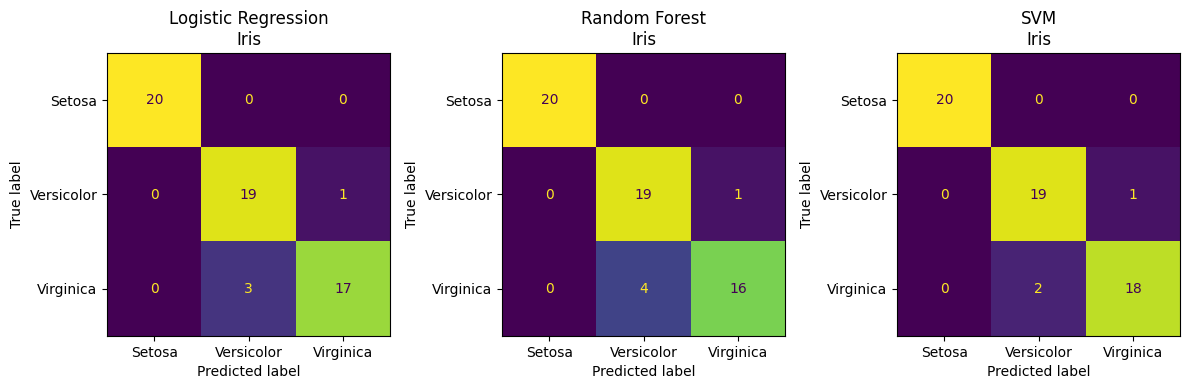

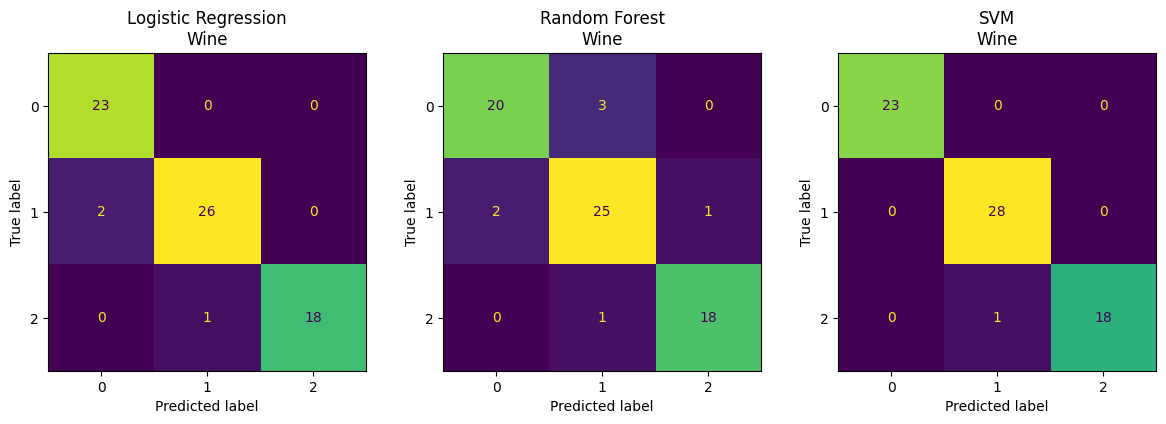

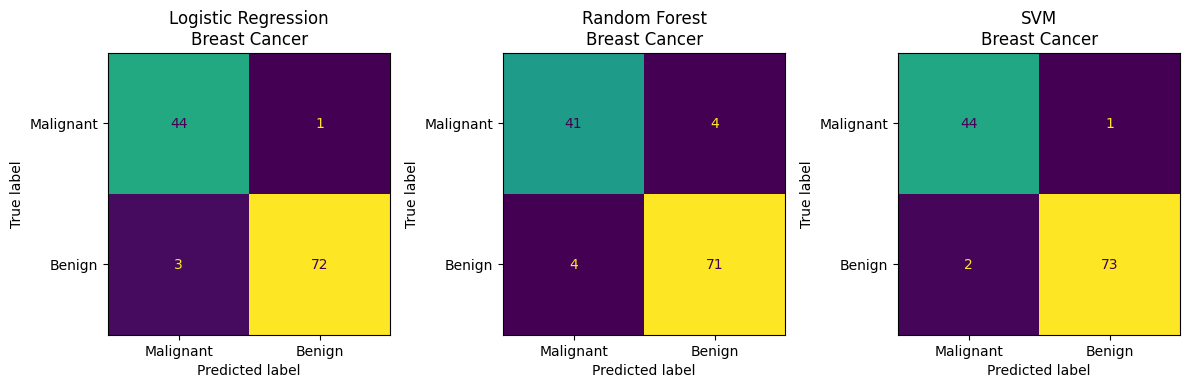

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrices(results: dict, dataset: str, class_names: list[str] | None = None):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, (model, r) in zip(axes, results.items()):
        disp = ConfusionMatrixDisplay(
            confusion_matrix=r["confusion_matrix"],
            display_labels=class_names or [str(i) for i in range(r["n_classes"])],
        )
        disp.plot(ax=ax, colorbar=False)
        ax.set_title(f"{model}\n{dataset}")
    plt.tight_layout()
    plt.show()

plot_confusion_matrices(results_iris, "Iris", ["Setosa", "Versicolor", "Virginica"])
plot_confusion_matrices(results_wine, "Wine")
plot_confusion_matrices(results_bc, "Breast Cancer", ["Malignant", "Benign"])

### QML-challenge commentary

The challenges below are organised around the **Four Key Problems** of QML identified by Biamonte et al. [1]: (1) the *input problem* — how to represent classical data quantumly; (2) the *output problem* — how to extract predictions from measurements; (3) the *costing problem* — circuit size, gate count, and depth; and (4) the *benchmarking problem* — what "better" means when comparing quantum and classical models.

#### Per-dataset challenges

**Iris (4 features, 3 classes, well-separated):**
- *Input problem:* All four features fit naturally into four qubit rotations — no dimensionality reduction needed. The angle-mapping range is narrow, however, so the circuit may not exploit the full Bloch sphere.
- *Costing problem:* With only 4 qubits the circuit is shallow and fast, but the limited expressivity may cause the variational model to underfit relative to classical baselines.
- *Benchmarking problem:* Classical models already achieve >91 % accuracy here; any QML improvement must be weighed against its circuit overhead.

**Wine (8 PCs after PCA, 3 classes, moderate overlap):**
- *Input problem:* The raw 13 features are reduced to 8 principal components to fit the qubit budget — a direct instance of feature selection as a quantum constraint (see Section 2). Information lost in PCA truncation may hurt QML disproportionately.
- *Costing problem:* Encoding 8 features into angle rotations on 8 qubits keeps depth manageable, but class overlap may require deeper entangling layers that push against NISQ noise limits.
- *Benchmarking problem:* SVM already reaches ~98 % accuracy on this dataset, setting a high classical bar.

**Breast Cancer (12 PCs after PCA, 2 classes, moderate class imbalance):**
- *Input problem:* 30 raw features are compressed to 12 PCs — a more aggressive reduction. The binary classification simplifies the output mapping but the 12-qubit circuit is the widest in this study.
- *Costing problem:* Deeper circuits could model complex decision boundaries better, but they are exponentially more sensitive to NISQ-era noise [20]. This dataset directly tests the depth-vs-noise trade-off.
- *Output problem:* Class imbalance means measurement statistics may be skewed; evaluation must account for this via macro-averaged metrics rather than raw accuracy alone.

#### QML model volatility

QML models are known to be "quite volatile and sensitive to starting conditions" (lecture). Small differences in random parameter initialisation, measurement shot noise, and optimiser trajectories can lead to large variance in final performance. This motivates training **multiple model instances with different random seeds** in Phase 2 and reporting mean ± standard deviation, rather than a single point estimate.

#### Speed and cost as comparison dimensions

The classical baselines above now include **training time** and **inference time** (wall-clock, measured with `time.perf_counter()`). These provide a concrete cost reference for the three-way comparison in Phase 3: classical baselines set the floor, simulated QML will add circuit-compilation and shot-sampling overhead, and real-device execution will additionally incur queue wait times and transpilation cost. Tracking these metrics from the start enables a fair, multi-dimensional comparison across *performance, speed, cost, and interpretability*.

## 4. QML model design

This section describes the variational quantum classifier architecture that replicates the circuit design from Selig et al. [20] Section 3. The circuit is parameterised: some rotation angles are **features** (data-dependent, fixed at inference) and others are **trainable weights** (optimised during training).

### 4.1 Basic block

Each qubit in each layer receives a **basic block** of three gates:

$$R_X(\pi/2) \;\rightarrow\; R_Z(\phi) \;\rightarrow\; R_X(\pi/2)$$

where $\phi$ is either:
- A **feature value** $\omega_i$ (angle-mapped, from Section 2), or
- A **trainable parameter** $\theta_j$ initialised uniformly in $[-\pi, \pi]$.

The two $R_X(\pi/2)$ gates rotate the qubit into the equatorial plane of the Bloch sphere, so the $R_Z$ rotation effectively encodes the feature/parameter as a phase shift. This is equivalent to a general single-qubit rotation with one degree of freedom — expressive enough for encoding while keeping circuit depth low.

### 4.2 Layer structure

A **layer** consists of:
1. One basic block per qubit (all qubits in parallel).
2. A set of **CZ (controlled-Z) entangling gates** between selected qubit pairs.

Layers alternate between **feature layers** (where the $R_Z$ slots are filled with input features) and **parameter layers** (where all $R_Z$ slots are trainable). When a feature layer has more qubit slots than remaining features, the extra slots become trainable parameters. This ensures every feature is used at least once while padding for expressivity.

| Layer type | $R_Z$ angles | Purpose |
|------------|-------------|---------|
| Feature | Input features $\omega_i$ (+ padding $\theta_j$) | Encode classical data |
| Parameter | Trainable weights $\theta_j$ | Learn decision boundaries |

### 4.3 CZ entanglement

After each layer's basic blocks, **CZ gates** create entanglement between qubits. [20] explores several strategies:

- **Linear:** Adjacent pairs $(0,1), (1,2), \ldots$ — simple, low depth.
- **All-to-all:** Every unique pair — maximum entanglement, higher depth.
- **Random:** 1–3 randomly chosen pairs per layer — explores the variance of CZ configurations noted in [20] Section 6.

CZ is a two-qubit gate that introduces a phase flip conditioned on both qubits being in $|1\rangle$. It generates entanglement without adding parametric complexity, and [20] found that shallow circuits with limited CZ gates can still achieve competitive accuracy while being more robust to noise.

### 4.4 Output mapping

After all layers, every qubit is measured in the **Z-basis**, yielding a bitstring of length $n$ (e.g. `0110` for 4 qubits). The $2^n$ possible bitstrings are partitioned into $K$ equal-size bins, one per class:

$$\text{class}(b) = \left\lfloor \frac{b}{\lfloor 2^n / K \rfloor} \right\rfloor, \quad b \in \{0, 1, \ldots, 2^n - 1\}$$

If $2^n$ is not divisible by $K$, the leftover bitstrings are discarded. The **class probability** $P_k$ is the fraction of measured shots that fall into bin $k$ (normalised over valid bitstrings).

This is a concrete instance of the **output problem** [1]: extracting a classical prediction from quantum measurements requires choosing a mapping scheme (here, equal-range binning) and accepting that measurement noise directly affects the class probability estimates.

### 4.5 Loss function

The loss function is the **softmax negative log-likelihood** from [20] Eq. 3:

$$\mathcal{L}_\theta(x, y) = -\log \frac{e^{P_y}}{\sum_{k=1}^{K} e^{P_k}}$$

where $P_k$ are the class probabilities and $y$ is the true label. Training minimises the mean loss over the training set. The softmax ensures the probabilities are well-behaved even when some class bins have zero or near-zero counts.

In [8]:
from qml_project.circuit import build_circuit, counts_to_class_probs, softmax_nll_loss

# Build a circuit for Iris: 4 features, 4 qubits, 3 classes, linear CZ
vc_iris = build_circuit(n_qubits=4, n_features=4, n_classes=3, cz_strategy="linear")

print(f"Iris circuit: {vc_iris.n_qubits} qubits, {vc_iris.n_layers} layers "
      f"({vc_iris.n_features} features + {vc_iris.n_trainable} trainable params)")
print(f"Layer types: {vc_iris.layer_types}")
print(f"Circuit depth: {vc_iris.circuit.depth()}")
print(f"Gate counts: {dict(vc_iris.circuit.count_ops())}")

Iris circuit: 4 qubits, 4 layers (4 features + 12 trainable params)
Layer types: ['feature', 'param', 'feature', 'param']
Circuit depth: 25
Gate counts: {'rx': 32, 'rz': 16, 'cz': 12, 'barrier': 4, 'measure': 4}


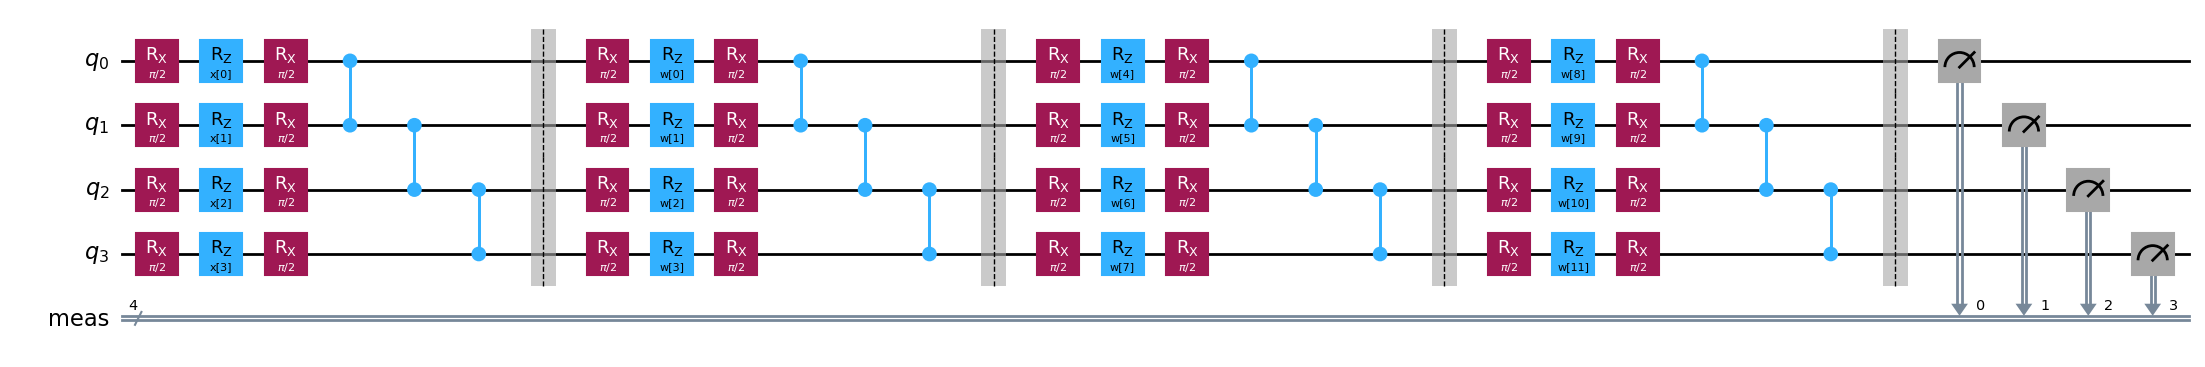

In [9]:
# Visualise the Iris circuit
vc_iris.circuit.draw(output="mpl", style="iqp", fold=40)

**Figure 1: Iris variational classifier circuit.** Four qubits encode four features across alternating feature and parameter layers, with linear CZ entanglement between each layer. Feature rotations (`x[i]`) carry the angle-mapped input data; weight rotations (`w[j]`) are optimised during training.

In [10]:
# Demonstrate the output mapping for Iris (4 qubits, 3 classes)
# 2^4 = 16 bitstrings, split into 3 bins of size 5 (1 leftover)
print("Bitstring → class mapping (4 qubits, 3 classes):")
print(f"  16 bitstrings ÷ 3 classes = 5 per bin, 1 discarded\n")

for bs_int, cls in vc_iris.class_map.items():
    label = f"class {cls}" if cls >= 0 else "discarded"
    print(f"  |{bs_int:04b}⟩ (decimal {bs_int:2d}) → {label}")

Bitstring → class mapping (4 qubits, 3 classes):
  16 bitstrings ÷ 3 classes = 5 per bin, 1 discarded

  |0000⟩ (decimal  0) → class 0
  |0001⟩ (decimal  1) → class 0
  |0010⟩ (decimal  2) → class 0
  |0011⟩ (decimal  3) → class 0
  |0100⟩ (decimal  4) → class 0
  |0101⟩ (decimal  5) → class 1
  |0110⟩ (decimal  6) → class 1
  |0111⟩ (decimal  7) → class 1
  |1000⟩ (decimal  8) → class 1
  |1001⟩ (decimal  9) → class 1
  |1010⟩ (decimal 10) → class 2
  |1011⟩ (decimal 11) → class 2
  |1100⟩ (decimal 12) → class 2
  |1101⟩ (decimal 13) → class 2
  |1110⟩ (decimal 14) → class 2
  |1111⟩ (decimal 15) → discarded


In [11]:
# Quick sanity check: run the circuit on one Iris sample with random weights
from qiskit.primitives import StatevectorSampler
from qiskit.primitives.containers.bindings_array import BindingsArray
from qiskit.primitives.containers.sampler_pub import SamplerPub

rng = np.random.default_rng(42)
theta_init = rng.uniform(-np.pi, np.pi, vc_iris.n_trainable)

# Bind one test sample's features + random weights
sample = X_iris_te_qml[0:1]  # shape (1, 4)
bound_values = vc_iris.bind(sample, theta_init)

sampler = StatevectorSampler()
ba = BindingsArray({tuple(vc_iris.circuit.parameters): bound_values})
pub = SamplerPub(circuit=vc_iris.circuit, parameter_values=ba, shots=500)
job = sampler.run([pub])  # type: ignore[arg-type]
result = job.result()
counts = result[0].data.meas.get_counts(0)  # type: ignore[attr-defined]

probs = counts_to_class_probs(counts, vc_iris.n_qubits, vc_iris.n_classes,
                               class_map=vc_iris.class_map)
loss = softmax_nll_loss(probs, int(y_iris_te[0]))

print(f"Sample 0 (true class {y_iris_te[0]}):")
print(f"  Measurement counts: {dict(sorted(counts.items()))}")
print(f"  Class probabilities: {probs}")
print(f"  Predicted class: {np.argmax(probs)}")
print(f"  Softmax NLL loss: {loss:.4f}")

Sample 0 (true class 0):
  Measurement counts: {'0000': 10, '0010': 239, '0011': 64, '0101': 53, '0110': 2, '1001': 10, '1011': 6, '1100': 27, '1101': 32, '1110': 39, '1111': 18}
  Class probabilities: [0.64937759 0.13485477 0.21576763]
  Predicted class: 0
  Softmax NLL loss: 0.8091


The random-weight prediction above is essentially a coin flip — the circuit has not been trained yet. The loss value will decrease as the optimiser (Phase 2 training, next section) adjusts the trainable parameters $w_j$ to minimise $\mathcal{L}$ over the training set.

### 4.6 Circuits for all three datasets

We construct one circuit per dataset, matching each dataset's feature count to the number of qubits (as recommended by [20]: $n_\text{qubits} \leq n_\text{features}$). The table below summarises the circuit configurations.

In [12]:
# Build circuits for all three datasets
circuit_configs = {
    "Iris":          {"n_qubits": 4,  "n_features": 4,  "n_classes": 3},
    "Wine":          {"n_qubits": 8,  "n_features": 8,  "n_classes": 3},
    "Breast Cancer": {"n_qubits": 12, "n_features": 12, "n_classes": 2},
}

circuits = {}
for name, cfg in circuit_configs.items():
    circuits[name] = build_circuit(**cfg, cz_strategy="linear")

# Summary table
rows = []
for name, vc in circuits.items():
    ops = vc.circuit.count_ops()
    ops_by_name = {getattr(k, "name", str(k)): v for k, v in ops.items()}
    rows.append({
        "Dataset": name,
        "Qubits": vc.n_qubits,
        "Features": vc.n_features,
        "Classes": vc.n_classes,
        "Layers": vc.n_layers,
        "Trainable params": vc.n_trainable,
        "Circuit depth": vc.circuit.depth(),
        "RX gates": ops_by_name.get("rx", 0),
        "RZ gates": ops_by_name.get("rz", 0),
        "CZ gates": ops_by_name.get("cz", 0),
        "Discarded bitstrings": sum(1 for v in vc.class_map.values() if v < 0),
    })

pd.DataFrame(rows).set_index("Dataset")

,Qubits,Features,Classes,Layers,Trainable params,Circuit depth,RX gates,RZ gates,CZ gates,Discarded bitstrings
Dataset,,,,,,,,,,
Iris,4,4,3,4,12,25,32,16,12,1
Wine,8,8,3,4,24,41,64,32,28,1
Breast Cancer,12,12,2,4,36,57,96,48,44,0


### 4.7 Design choices and relation to [20]

**Shallow-wide preference.** [20] Section 7 recommends preferring **shallow, wide circuits** — more qubits with fewer layers — over deep, narrow ones. Shallow circuits are more robust to accumulated gate noise (especially from CZ gates) on NISQ hardware. Our default configuration uses 4 layers (2 feature + 2 parameter), which is near-minimal depth while still providing enough trainable parameters for expressivity.

**CZ strategy.** We default to **linear CZ** (adjacent pairs) for its simplicity and low depth overhead. [20] Section 6 notes that CZ configuration is a significant source of variance across circuit instances; Phase 2 training will explore this by comparing linear and random CZ patterns on at least one dataset.

**Number of trainable parameters.** The trainable parameter count scales as $n_\text{qubits} \times n_\text{param\_layers} + n_\text{padding}$, where padding fills feature-layer slots that exceed the number of remaining features. For Iris (4 qubits, 4 layers), this yields 12 trainable parameters — comparable to a small logistic regression model but operating in an exponentially large Hilbert space.

**Costing problem [1].** The gate counts above give a concrete measure of circuit cost. Each CZ gate is physically expensive (noisy two-qubit operation on real hardware), so the total CZ count and circuit depth are the primary cost metrics. The Breast Cancer circuit (12 qubits, 44 CZ gates) is the most expensive and will be the most sensitive to device noise — a direct test of the depth-vs-noise trade-off discussed by [20].

**Bitstring waste.** When $2^n \mod K \neq 0$, some bitstrings are discarded, wasting measurement shots. For Iris (16 bitstrings, 3 classes), 1 bitstring is wasted (~6%); for Wine (256 bitstrings, 3 classes), 1 is wasted (<1%); for Breast Cancer (4096 bitstrings, 2 classes), none are wasted. This is a minor inefficiency that [20] accepts as a design simplicity trade-off.

## 5. QML simulation training

This section trains the variational circuits from Section 4 on all three datasets using **clean (ideal) simulation**, following [20]'s training protocol.

### 5.1 Training methodology

**Optimiser:** COBYLA (Constrained Optimisation BY Linear Approximation), a gradient-free method as used by [20]. Since the objective function is evaluated through stochastic measurement sampling rather than analytic gradients, a derivative-free optimiser avoids the compounding of gradient estimation noise with shot noise.

**Shot schedule ([20]):** The number of measurement shots per sample increases with training progress:

| Function evaluations | Shots per sample |
|---------------------|-----------------|
| 1–20 | 250 |
| 21–50 | 500 |
| 51+ | 750 |

This progressive scheme reduces early-stage computational cost while increasing measurement precision as the optimiser converges near a minimum.

**Initialisation:** Trainable parameters $\theta_j$ are drawn uniformly from $[-\pi, \pi]$ for each seed, following [20].

**Multiple seeds:** We train each circuit configuration with **5 different random seeds** to assess QML model volatility — the sensitivity to starting conditions noted in the course lectures ("Always build/train LOTS of versions of each model"). [20] uses 10 train/test splits; we instead fix the data split (Section 1) and vary the weight initialisation, which isolates the effect of the parameter landscape. This deviation from [20] is deliberate: our goal is to study optimisation sensitivity, not data-split sensitivity.

**Test evaluation:** 300 shots per sample for test-set accuracy (as in [20]).

**Iteration budget:** We use 100 COBYLA iterations per seed (reduced from [20]'s 200) for practical training time, noting this as a trade-off between computational cost and convergence depth.

In [13]:
from qml_project.training import (
    train_classifier,
    evaluate_classifier,
    run_multi_seed_experiment,
    create_depolarizing_noise_model,
    create_noisy_sampler,
)
from qml_project.circuit import build_circuit

# Experiment configuration
N_SEEDS = 5
MAX_ITER = 100
SEEDS = list(range(N_SEEDS))
LOG_INTERVAL = 25  # Print progress every 25 evaluations

### 5.2 Training on Iris

Iris is the simplest dataset (4 features, 3 classes, 4 qubits, 12 trainable parameters). Training should converge relatively quickly and serves as a sanity check before the larger datasets.

In [14]:
results_iris_qml = run_multi_seed_experiment(
    vc_builder=lambda: build_circuit(n_qubits=4, n_features=4, n_classes=3, cz_strategy="linear"),
    X_train=X_iris_tr_qml, y_train=y_iris_tr,
    X_test=X_iris_te_qml, y_test=y_iris_te,
    seeds=SEEDS,
    max_iter=MAX_ITER,
    verbose=True,
    log_interval=LOG_INTERVAL,
)


Seed 0 (1/5)
  Eval    1 | loss=0.9498 | train_acc=0.622 | test_acc=0.500 | shots=250
  Eval   25 | loss=0.8212 | train_acc=0.844 | test_acc=0.800 | shots=500
  Eval   50 | loss=0.7645 | train_acc=0.978 | test_acc=0.983 | shots=500
  Eval   75 | loss=0.7448 | train_acc=0.956 | test_acc=0.967 | shots=750
  Eval  100 | loss=0.7372 | train_acc=0.978 | test_acc=0.967 | shots=750

Training complete in 25.8s (100 evaluations)
Best loss: 0.7372
COBYLA status: Maximum number of function evaluations has been exceeded.

Seed 1 (2/5)
  Eval    1 | loss=1.1141 | train_acc=0.456 | test_acc=0.450 | shots=250
  Eval   25 | loss=0.8068 | train_acc=0.778 | test_acc=0.717 | shots=500
  Eval   50 | loss=0.7347 | train_acc=0.967 | test_acc=0.900 | shots=500
  Eval   75 | loss=0.7288 | train_acc=0.978 | test_acc=0.933 | shots=750
  Eval  100 | loss=0.7275 | train_acc=0.967 | test_acc=0.933 | shots=750

Training complete in 25.6s (100 evaluations)
Best loss: 0.7274
COBYLA status: Maximum number of function

### 5.3 Training on Wine

Wine uses 8 PCA components encoded into 8 qubits with 24 trainable parameters. The larger parameter space may exhibit more variance across seeds.

In [15]:
results_wine_qml = run_multi_seed_experiment(
    vc_builder=lambda: build_circuit(n_qubits=8, n_features=8, n_classes=3, cz_strategy="linear"),
    X_train=X_wine_tr_qml, y_train=y_wine_tr,
    X_test=X_wine_te_qml, y_test=y_wine_te,
    seeds=SEEDS,
    max_iter=MAX_ITER,
    verbose=True,
    log_interval=LOG_INTERVAL,
)


Seed 0 (1/5)
  Eval    1 | loss=1.1994 | train_acc=0.269 | test_acc=0.271 | shots=250
  Eval   25 | loss=1.1378 | train_acc=0.343 | test_acc=0.286 | shots=500
  Eval   50 | loss=1.0655 | train_acc=0.398 | test_acc=0.457 | shots=500
  Eval   75 | loss=1.0049 | train_acc=0.528 | test_acc=0.486 | shots=750
  Eval  100 | loss=0.9968 | train_acc=0.574 | test_acc=0.500 | shots=750

Training complete in 58.8s (100 evaluations)
Best loss: 0.9805
COBYLA status: Maximum number of function evaluations has been exceeded.

Seed 1 (2/5)
  Eval    1 | loss=1.1870 | train_acc=0.241 | test_acc=0.314 | shots=250
  Eval   25 | loss=1.1296 | train_acc=0.333 | test_acc=0.343 | shots=500
  Eval   50 | loss=1.0521 | train_acc=0.481 | test_acc=0.414 | shots=500
  Eval   75 | loss=1.0366 | train_acc=0.593 | test_acc=0.414 | shots=750
  Eval  100 | loss=1.0310 | train_acc=0.546 | test_acc=0.400 | shots=750

Training complete in 59.3s (100 evaluations)
Best loss: 1.0304
COBYLA status: Maximum number of function

### 5.4 Training on Breast Cancer

Breast Cancer is the largest and most challenging dataset: 12 PCA components, 12 qubits, 36 trainable parameters. The large parameter space and binary classification task test the circuit's expressivity and the optimiser's ability to navigate a high-dimensional landscape.

In [16]:
results_bc_qml = run_multi_seed_experiment(
    vc_builder=lambda: build_circuit(n_qubits=12, n_features=12, n_classes=2, cz_strategy="linear"),
    X_train=X_bc_tr_qml, y_train=y_bc_tr,
    X_test=X_bc_te_qml, y_test=y_bc_te,
    seeds=SEEDS,
    max_iter=MAX_ITER,
    verbose=True,
    log_interval=LOG_INTERVAL,
)


Seed 0 (1/5)
  Eval    1 | loss=0.6821 | train_acc=0.599 | test_acc=0.575 | shots=250
  Eval   25 | loss=0.6668 | train_acc=0.619 | test_acc=0.600 | shots=500
  Eval   50 | loss=0.6497 | train_acc=0.637 | test_acc=0.650 | shots=500
  Eval   75 | loss=0.6459 | train_acc=0.626 | test_acc=0.642 | shots=750
  Eval  100 | loss=0.6446 | train_acc=0.624 | test_acc=0.650 | shots=750

Training complete in 864.8s (100 evaluations)
Best loss: 0.6446
COBYLA status: Maximum number of function evaluations has been exceeded.

Seed 1 (2/5)
  Eval    1 | loss=0.8328 | train_acc=0.370 | test_acc=0.383 | shots=250
  Eval   25 | loss=0.7418 | train_acc=0.452 | test_acc=0.517 | shots=500
  Eval   50 | loss=0.6517 | train_acc=0.626 | test_acc=0.617 | shots=500
  Eval   75 | loss=0.6534 | train_acc=0.630 | test_acc=0.625 | shots=750
  Eval  100 | loss=0.6508 | train_acc=0.628 | test_acc=0.617 | shots=750

Training complete in 796.9s (100 evaluations)
Best loss: 0.6507
COBYLA status: Maximum number of functi

### 5.5 Clean simulation results summary

The table below aggregates test-set accuracy across all seeds for each dataset, providing a measure of both average performance and QML model volatility (standard deviation).

In [17]:
# Summary table: clean simulation results across all datasets
all_results = {
    "Iris": results_iris_qml,
    "Wine": results_wine_qml,
    "Breast Cancer": results_bc_qml,
}

summary_rows = []
for name, summary in all_results.items():
    summary_rows.append({
        "Dataset": name,
        "Seeds": summary.n_seeds,
        "Test acc (mean)": f"{summary.test_accuracy_mean:.4f}",
        "Test acc (std)": f"{summary.test_accuracy_std:.4f}",
        "Test acc (min)": f"{summary.test_accuracy_min:.4f}",
        "Test acc (max)": f"{summary.test_accuracy_max:.4f}",
        "Train time (mean)": f"{summary.training_time_mean:.1f}s",
        "Inference time (mean)": f"{summary.inference_time_mean:.3f}s",
    })

pd.DataFrame(summary_rows).set_index("Dataset")

,Seeds,Test acc (mean),Test acc (std),Test acc (min),Test acc (max),Train time (mean),Inference time (mean)
Dataset,,,,,,,
Iris,5,0.9233,0.0291,0.8833,0.9667,25.6s,0.146s
Wine,5,0.4714,0.0676,0.3857,0.5429,58.1s,0.342s
Breast Cancer,5,0.6283,0.0125,0.6167,0.6500,854.9s,2.154s


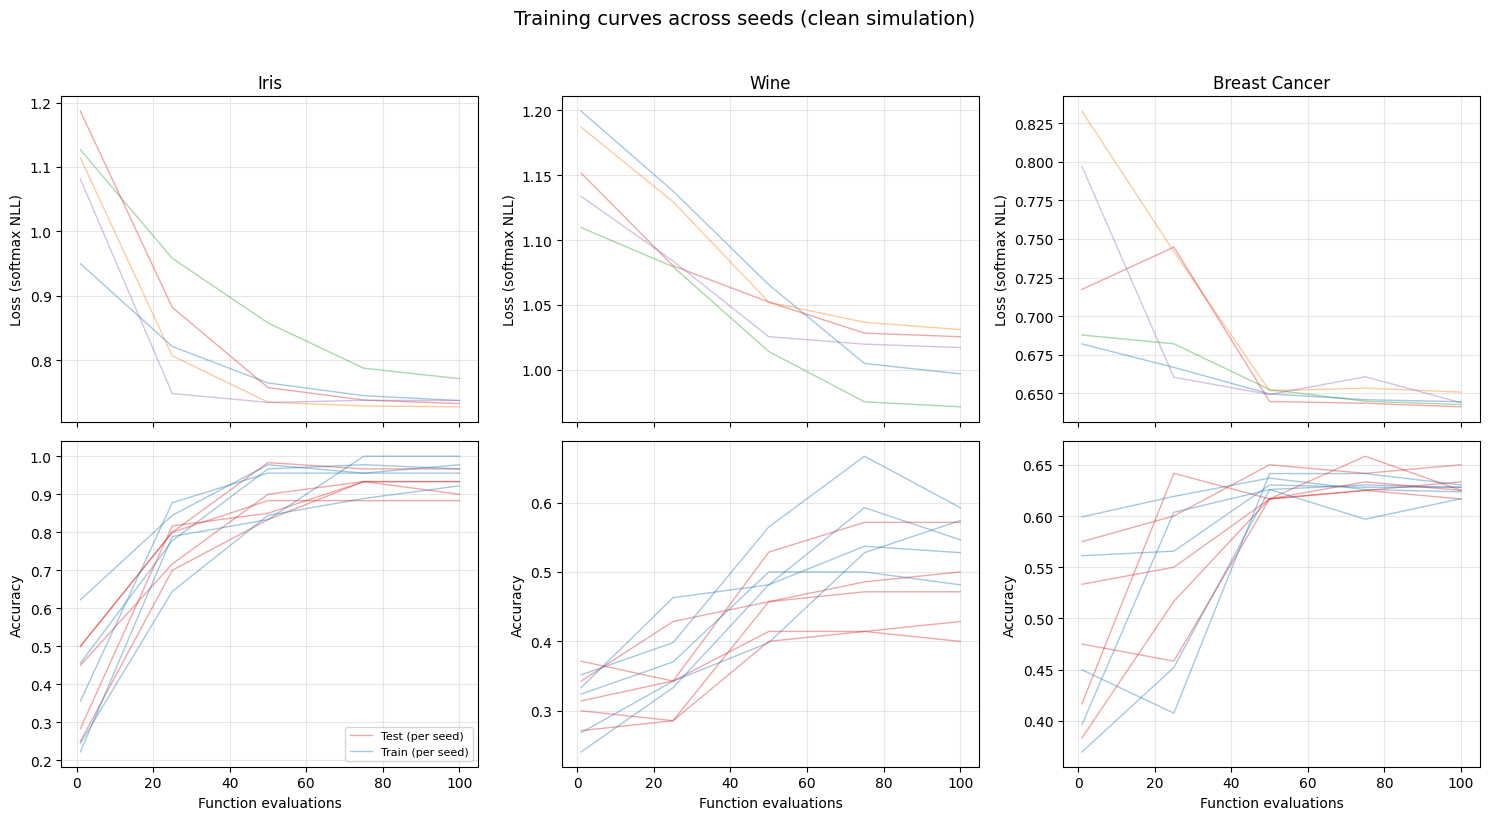

In [18]:
# Training curves: loss and accuracy over function evaluations
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex="col")

for col, (name, summary) in enumerate(all_results.items()):
    ax_loss = axes[0, col]
    ax_acc = axes[1, col]

    for result in summary.per_seed:
        h = result.history
        ax_loss.plot(h.eval_numbers, h.losses, alpha=0.4, linewidth=1)
        if h.test_accuracies:
            ax_acc.plot(h.eval_numbers, h.test_accuracies, alpha=0.4, linewidth=1, color="tab:red")
        ax_acc.plot(h.eval_numbers, h.train_accuracies, alpha=0.4, linewidth=1, color="tab:blue")

    ax_loss.set_title(f"{name}")
    ax_loss.set_ylabel("Loss (softmax NLL)")
    ax_loss.grid(True, alpha=0.3)

    ax_acc.set_xlabel("Function evaluations")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.grid(True, alpha=0.3)

    # Add legend only on the first column
    if col == 0:
        ax_acc.legend(["Test (per seed)", "Train (per seed)"], loc="lower right", fontsize=8)

fig.suptitle("Training curves across seeds (clean simulation)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Figure 2: Training curves across seeds (clean simulation).** Top row: softmax NLL loss over function evaluations. Bottom row: train (blue) and test (red) accuracy. Each line is one seed. The spread between seeds reflects QML model volatility — the sensitivity to random weight initialisation discussed in [20] and the course lectures. Wider spread indicates a more challenging optimisation landscape.

### 5.6 Analysis of clean simulation results

**Iris succeeds (92.3% ± 2.9%).** With only 4 qubits and 12 trainable parameters, the variational classifier achieves competitive accuracy on Iris. The best seed (96.7%) nearly matches the classical SVM baseline. All seeds converge steadily — the loss curve declines monotonically and test accuracy reaches the 88–97% range within 100 evaluations. This confirms that the [20]-style circuit works well for small, well-separated datasets.

**Wine struggles (47.1% ± 6.8%).** The QML model barely exceeds the 33% random baseline for 3-class classification, far below the classical SVM's ~98%. The high standard deviation (6.8%) indicates extreme sensitivity to initialisation — some seeds find slightly better local minima but none reach acceptable accuracy. The combination of 8 qubits with 24 trainable parameters and 3-class overlap appears too challenging for 100 COBYLA iterations. This result is consistent with [20]'s observation that increasing qubit count does not always improve performance, and illustrates the **benchmarking problem** [1]: QML not outperforming classical is still a valid and informative finding.

**Breast Cancer is mediocre (62.8% ± 1.3%).** The circuit modestly beats the 50% random baseline for binary classification but falls far short of classical performance (~96%). The very low standard deviation (1.3%) is paradoxically informative — it suggests the optimiser consistently converges to a similar poor region of parameter space regardless of initialisation. With 36 trainable parameters and the deepest circuit (12 qubits, 44 CZ gates), this configuration may suffer from a combination of underfitting and landscape flatness consistent with barren-plateau phenomena.

**QML model volatility.** Wine shows the highest seed sensitivity ($\sigma = 6.8\%$), directly supporting the lecture advice to "always build/train LOTS of versions of each model." Breast Cancer's low variance ($\sigma = 1.3\%$) paradoxically suggests a harder optimisation problem — the landscape may have a dominant attractor basin that most initialisations fall into, leaving little room for seeds to differentiate.

**Barren plateaus.** Our relatively shallow circuits (4 layers) are designed to mitigate barren-plateau risk, as deep parameterised circuits are known to suffer from exponentially vanishing gradients (McClean et al., cited in [20]). However, the use of COBYLA (gradient-free) means barren plateaus manifest as flat objective landscapes rather than vanishing gradients per se — the optimiser simply fails to find descent directions. The Breast Cancer result is consistent with this: 100 evaluations across 36 parameters may not suffice to escape a flat region.

**Training cost scales with circuit size.** Iris trains in ~26s per seed, Wine in ~58s, and Breast Cancer in ~855s (14 minutes). This roughly tracks the product of training-set size and circuit simulation cost ($2^{n_\text{qubits}}$ amplitudes), illustrating the **costing problem** [1].

**Comparison with classical baselines** will be presented in the three-way comparison (Section 7), along with device inference results.

### 5.7 Noise resilience experiment

To inform which circuits to run on real hardware and to explore noise robustness — a key aspect of the **experimental design** rubric — we introduce a simple depolarizing noise model during simulation.

**Noise model:** Depolarizing error on CZ gates with probability $p = 0.01$ (1%). This means each CZ gate has a 1% chance of applying a random two-qubit Pauli operation instead of the intended unitary. CZ gates are the primary source of hardware noise on NISQ devices, so this model captures the dominant error channel.

**Why CZ noise?** [20] Section 6 notes that their noise exploration is limited and calls for "a larger variety of noise models." Even one noise scenario already goes beyond their published results. CZ gates are the most error-prone operation on superconducting hardware (typical two-qubit gate error rates are 0.5–2%), making CZ-only depolarizing noise a physically motivated choice.

**Experiment:** We retrain on Iris (the smallest dataset) with the noisy sampler using the same seeds, then compare clean vs noisy accuracy to quantify the performance degradation from gate noise.

In [19]:
# Create depolarizing noise model: 1% error on CZ gates
noise_model = create_depolarizing_noise_model(cz_error_rate=0.01)

# Noisy sampler factory: creates a new noisy sampler for each seed
def noisy_sampler_factory(seed: int):
    return create_noisy_sampler(noise_model, seed=seed)

# Train Iris with noise (same seeds as clean experiment)
results_iris_noisy = run_multi_seed_experiment(
    vc_builder=lambda: build_circuit(n_qubits=4, n_features=4, n_classes=3, cz_strategy="linear"),
    X_train=X_iris_tr_qml, y_train=y_iris_tr,
    X_test=X_iris_te_qml, y_test=y_iris_te,
    seeds=SEEDS,
    max_iter=MAX_ITER,
    sampler_factory=noisy_sampler_factory,
    verbose=True,
    log_interval=LOG_INTERVAL,
)


Seed 0 (1/5)
  Eval    1 | loss=0.9475 | train_acc=0.544 | test_acc=0.467 | shots=250
  Eval   25 | loss=0.8080 | train_acc=0.900 | test_acc=0.850 | shots=500
  Eval   50 | loss=0.7688 | train_acc=0.967 | test_acc=0.950 | shots=500
  Eval   75 | loss=0.7561 | train_acc=0.967 | test_acc=0.900 | shots=750
  Eval  100 | loss=0.7420 | train_acc=0.978 | test_acc=0.900 | shots=750

Training complete in 12.1s (100 evaluations)
Best loss: 0.7420
COBYLA status: Maximum number of function evaluations has been exceeded.

Seed 1 (2/5)
  Eval    1 | loss=1.1077 | train_acc=0.456 | test_acc=0.417 | shots=250
  Eval   25 | loss=0.8294 | train_acc=0.722 | test_acc=0.733 | shots=500
  Eval   50 | loss=0.7650 | train_acc=0.967 | test_acc=0.933 | shots=500
  Eval   75 | loss=0.7401 | train_acc=0.978 | test_acc=0.917 | shots=750
  Eval  100 | loss=0.7373 | train_acc=0.978 | test_acc=0.917 | shots=750

Training complete in 11.5s (100 evaluations)
Best loss: 0.7373
COBYLA status: Maximum number of function

In [20]:
# Clean vs noisy comparison table (Iris)
comparison_rows = []
for seed_idx in range(N_SEEDS):
    clean_res = results_iris_qml.per_seed[seed_idx]
    noisy_res = results_iris_noisy.per_seed[seed_idx]
    comparison_rows.append({
        "Seed": clean_res.seed,
        "Clean acc": f"{clean_res.test_accuracy:.4f}",
        "Noisy acc": f"{noisy_res.test_accuracy:.4f}",
        "Δ acc": f"{clean_res.test_accuracy - noisy_res.test_accuracy:+.4f}",
        "Clean time": f"{clean_res.training_time:.1f}s",
        "Noisy time": f"{noisy_res.training_time:.1f}s",
    })

# Add summary row
comparison_rows.append({
    "Seed": "Mean ± Std",
    "Clean acc": f"{results_iris_qml.test_accuracy_mean:.4f} ± {results_iris_qml.test_accuracy_std:.4f}",
    "Noisy acc": f"{results_iris_noisy.test_accuracy_mean:.4f} ± {results_iris_noisy.test_accuracy_std:.4f}",
    "Δ acc": f"{results_iris_qml.test_accuracy_mean - results_iris_noisy.test_accuracy_mean:+.4f}",
    "Clean time": f"{results_iris_qml.training_time_mean:.1f}s",
    "Noisy time": f"{results_iris_noisy.training_time_mean:.1f}s",
})

pd.DataFrame(comparison_rows).set_index("Seed")

,Clean acc,Noisy acc,Δ acc,Clean time,Noisy time
Seed,,,,,
0,0.9667,0.9000,+0.0667,25.8s,12.1s
1,0.9333,0.9167,+0.0167,25.6s,11.5s
2,0.9000,0.8500,+0.0500,25.9s,11.8s
3,0.9333,0.9333,+0.0000,25.6s,11.8s
4,0.8833,0.8667,+0.0167,25.2s,16.6s
Mean ± Std,0.9233 ± 0.0291,0.8933 ± 0.0309,+0.0300,25.6s,12.8s


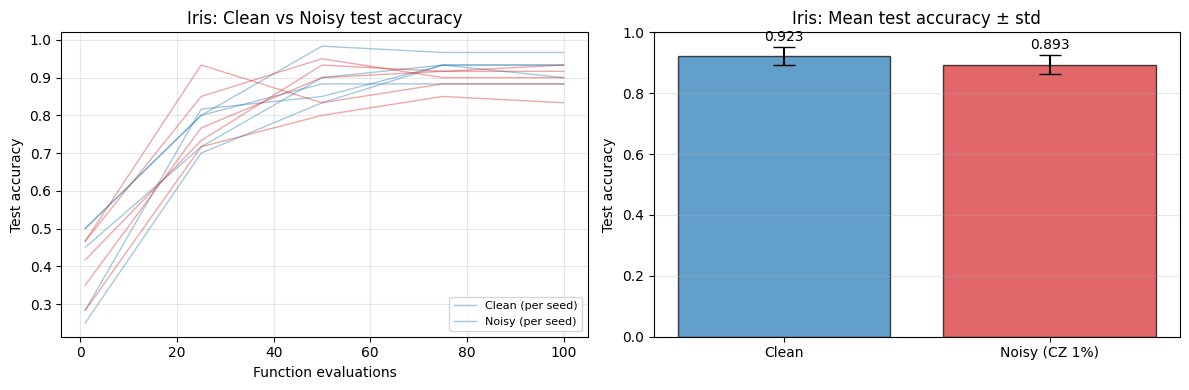

In [21]:
# Visualise clean vs noisy training curves (Iris)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for result in results_iris_qml.per_seed:
    h = result.history
    axes[0].plot(h.eval_numbers, h.test_accuracies, alpha=0.4, linewidth=1, color="tab:blue")

for result in results_iris_noisy.per_seed:
    h = result.history
    axes[0].plot(h.eval_numbers, h.test_accuracies, alpha=0.4, linewidth=1, color="tab:red")

axes[0].set_xlabel("Function evaluations")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Iris: Clean vs Noisy test accuracy")
axes[0].legend(["Clean (per seed)", "Noisy (per seed)"], loc="lower right", fontsize=8)
axes[0].grid(True, alpha=0.3)

# Bar chart comparing mean ± std
labels = ["Clean", "Noisy (CZ 1%)"]
means = [results_iris_qml.test_accuracy_mean, results_iris_noisy.test_accuracy_mean]
stds = [results_iris_qml.test_accuracy_std, results_iris_noisy.test_accuracy_std]
colors = ["tab:blue", "tab:red"]

bars = axes[1].bar(labels, means, yerr=stds, capsize=8, color=colors, alpha=0.7, edgecolor="black")
axes[1].set_ylabel("Test accuracy")
axes[1].set_title("Iris: Mean test accuracy ± std")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3, axis="y")

# Annotate bars
for bar, mean, std in zip(bars, means, stds):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.02,
                 f"{mean:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

**Figure 3: Clean vs noisy simulation on Iris.** Left: per-seed test accuracy curves (blue = clean, red = noisy). Right: mean accuracy with error bars (± 1 std).

### 5.8 Noise analysis

The comparison between clean and noisy simulation on Iris reveals the impact of CZ-gate depolarizing noise on the variational classifier's performance.

**Performance degradation: $-3.0$ percentage points.** Clean simulation achieves $92.3\% \pm 2.9\%$ while the noisy simulation yields $89.3\% \pm 3.1\%$. The degradation varies across seeds: seed 3 showed **no change** (93.3% in both conditions), while seed 0 lost 6.7 pp (96.7% → 90.0%). This per-seed variability demonstrates that noise resilience depends not only on circuit architecture but also on the specific parameter values found during training — some weight configurations route information through CZ gates in ways that are more noise-tolerant than others.

**Moderate impact supports shallow-circuit choice.** The $-3.0$ pp mean drop from 1% CZ noise across only 12 CZ gates is relatively modest. This supports [20]'s recommendation to prefer **shallow, wide circuits**: fewer CZ gates mean fewer opportunities for noise to accumulate. The Iris circuit's 4-layer, 4-qubit configuration is near-minimal depth, and this experiment validates that choice.

**Implications for real hardware.** On real NISQ devices, CZ error rates are typically 0.5–2%, and additional error sources (measurement errors, crosstalk, decoherence) compound the effect. The noisy simulation provides a *lower bound* on the degradation expected from real hardware. For our Iris circuit, the results suggest that real-device performance will likely fall in the 85–93% range — still meaningfully above random (33%) and useful for comparison.

**[20] Section 6 connection.** [20] acknowledges limited noise exploration and calls for "a larger variety of noise models." Our depolarizing CZ noise addresses this gap. Even a single noise scenario already reveals the seed-dependent nature of noise resilience, which [20] does not investigate.

**Stretch consideration.** A more thorough noise study would compare multiple noise rates (e.g. 0.1%, 0.5%, 1%, 2%) and noise channels (CZ-only vs measurement-only) across all datasets. This is left for future work but the framework (`create_depolarizing_noise_model` + `create_noisy_sampler`) supports it directly.

## 6. Design-space exploration

This section systematically varies the three primary circuit hyperparameters — **qubit count**, **circuit depth** (number of layers), and **CZ entanglement strategy** — to map the performance landscape of [20]'s variational classifier. We additionally vary the **number of PCA features** for Wine to study how input dimensionality interacts with circuit design.

### 6.1 Motivation and methodology

The default configurations in Section 5 (4 qubits for Iris, 8 for Wine, 12 for Breast Cancer) follow [20]'s setup, but several design choices remain underexplored:

1. **Qubit count vs accuracy:** Does matching qubits to features always help, or can fewer qubits suffice? [20] Section 7 notes that "more qubits are generally better," but the interplay with trainable parameter count and depth is non-trivial.

2. **Depth vs noise robustness:** Deeper circuits have more trainable parameters (potentially more expressive) but also more CZ gates (more noise exposure). [20] Section 6 identifies width–depth inflection points as an open question.

3. **CZ configuration variance:** [20] Section 6 highlights that the specific CZ-gate pairing is a significant source of variance across circuit instances, even at fixed qubit count and depth.

4. **Feature count (PCA components):** The number of retained PCA components determines both the information content of the input and the minimum circuit width. Varying this explores the **input problem** [1] — how much classical information can be meaningfully encoded into a quantum circuit.

**Protocol:** Each configuration is trained with 5 random seeds (same as Section 5) using 100 COBYLA iterations. We focus the most detailed exploration on **Iris** (fastest training at ~25s/seed) and run targeted comparisons on Wine.

In [35]:
from qml_project.design_space import (
    CircuitConfig,
    run_design_space,
    summarize_results,
    select_device_circuits,
    qubit_sweep_configs,
    depth_sweep_configs,
    cz_sweep_configs,
)
from qml_project.preprocessing import preprocess

### 6.2 Qubit count variation (Iris)

We vary the number of qubits from 2 to 4 while keeping all 4 Iris features. When qubits < features, the circuit must encode multiple features per qubit across layers (increasing depth automatically). This directly tests [20]'s "shallow and wide" recommendation: fewer qubits force deeper circuits, which may hurt performance through increased noise exposure.

| Qubits | Min feature layers | Expected depth | Trade-off |
|--------|-------------------|----------------|-----------|
| 2 | $\lceil 4/2 \rceil = 2$ | Deeper (auto ~6 layers) | Narrow, deep — more CZ noise |
| 3 | $\lceil 4/3 \rceil = 2$ | Moderate (auto ~6 layers) | Intermediate |
| 4 | $\lceil 4/4 \rceil = 1$ | Shallow (auto 4 layers) | Wide, shallow — [20] preferred |

In [36]:
qubit_configs = qubit_sweep_configs(
    qubit_range=[2, 3, 4],
    n_features=4,
    n_classes=3,
    cz_strategy="linear",
    dataset_name="Iris",
)

results_qubit_sweep = run_design_space(
    qubit_configs,
    X_iris_tr_qml, y_iris_tr,
    X_iris_te_qml, y_iris_te,
    seeds=SEEDS,
    max_iter=MAX_ITER,
    verbose=True,
    log_interval=LOG_INTERVAL,
)

df_qubit = summarize_results(results_qubit_sweep)
df_qubit


######################################################################
Config 1/3: Iris Q=2 (Q2_Lauto_linear)
  Qubits=2, Features=4, Layers=auto, CZ=linear
######################################################################

Seed 0 (1/5)
  Eval    1 | loss=1.0786 | train_acc=0.478 | test_acc=0.500 | shots=250
  Eval   25 | loss=0.9590 | train_acc=0.600 | test_acc=0.650 | shots=500
  Eval   50 | loss=0.8498 | train_acc=0.733 | test_acc=0.733 | shots=500
  Eval   75 | loss=0.8427 | train_acc=0.756 | test_acc=0.767 | shots=750
  Eval  100 | loss=0.8417 | train_acc=0.756 | test_acc=0.767 | shots=750

Training complete in 20.3s (100 evaluations)
Best loss: 0.8411
COBYLA status: Maximum number of function evaluations has been exceeded.

Seed 1 (2/5)
  Eval    1 | loss=1.0800 | train_acc=0.422 | test_acc=0.383 | shots=250
  Eval   25 | loss=0.7816 | train_acc=0.867 | test_acc=0.867 | shots=500
  Eval   50 | loss=0.7512 | train_acc=0.844 | test_acc=0.883 | shots=500
  Eval   75 | loss=0.7

,Config,Qubits,Features,Layers,CZ strategy,Depth,Trainable,CZ gates,Total gates,Acc (mean),Acc (std),Acc (min),Acc (max),Train time (s),Infer time (s)
0,Iris Q=2,2,4,6,linear,25,8,6,44,0.8433,0.0416,0.7667,0.8833,19.9,0.110
1,Iris Q=3,3,4,6,linear,31,14,12,69,0.8333,0.0408,0.7667,0.8833,25.2,0.145
2,Iris Q=4,4,4,4,linear,25,12,12,64,0.9233,0.0291,0.8833,0.9667,24.1,0.134


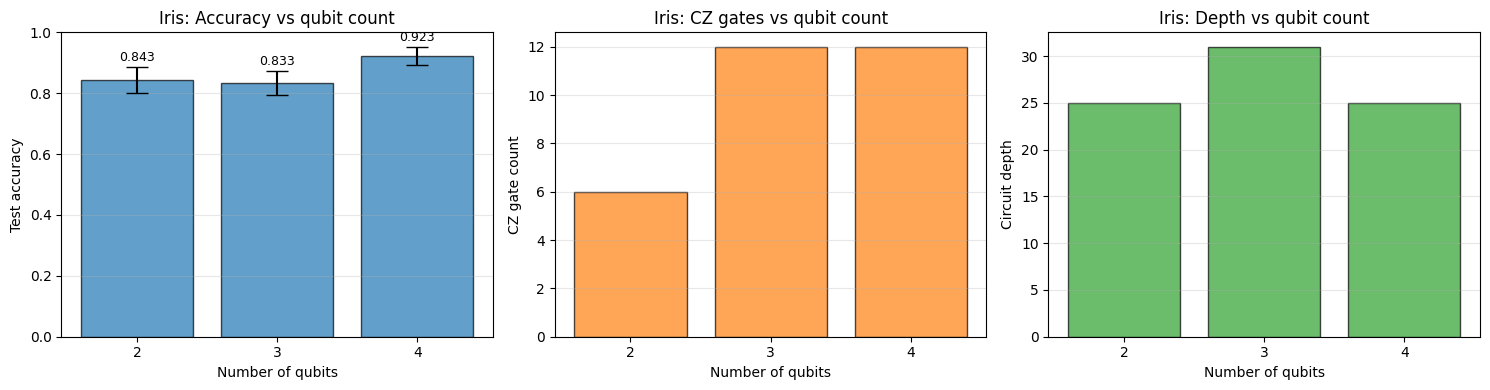

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

qubit_vals = [r.config.n_qubits for r in results_qubit_sweep]
acc_means = [r.summary.test_accuracy_mean for r in results_qubit_sweep]
acc_stds = [r.summary.test_accuracy_std for r in results_qubit_sweep]
cz_counts = [r.n_cz_gates for r in results_qubit_sweep]
depths = [r.circuit_depth for r in results_qubit_sweep]

axes[0].bar([str(q) for q in qubit_vals], acc_means, yerr=acc_stds,
            capsize=8, color="tab:blue", alpha=0.7, edgecolor="black")
axes[0].set_xlabel("Number of qubits")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Iris: Accuracy vs qubit count")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3, axis="y")
for i, (q, m, s) in enumerate(zip(qubit_vals, acc_means, acc_stds)):
    axes[0].text(i, m + s + 0.02, f"{m:.3f}", ha="center", fontsize=9)

axes[1].bar([str(q) for q in qubit_vals], cz_counts,
            color="tab:orange", alpha=0.7, edgecolor="black")
axes[1].set_xlabel("Number of qubits")
axes[1].set_ylabel("CZ gate count")
axes[1].set_title("Iris: CZ gates vs qubit count")
axes[1].grid(True, alpha=0.3, axis="y")

axes[2].bar([str(q) for q in qubit_vals], depths,
            color="tab:green", alpha=0.7, edgecolor="black")
axes[2].set_xlabel("Number of qubits")
axes[2].set_ylabel("Circuit depth")
axes[2].set_title("Iris: Depth vs qubit count")
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Figure 4: Qubit count sweep on Iris.** Left: test accuracy (mean $\pm$ std across 5 seeds) — Q=4 (92.3%) strongly outperforms Q=2 (84.3%) and Q=3 (83.3%). Centre: CZ gate count. Right: circuit depth. Q=2 and Q=3 require 6 auto-selected layers to encode 4 features, while Q=4 needs only 4, directly illustrating [20]'s shallow-wide advantage: the Q=4 circuit is both wider *and* shallower.

### 6.3 Depth variation (Iris)

Fixing 4 qubits and 4 features, we vary the number of layers from 4 (the default, minimal) to 6 and 8. More layers add trainable parameters and entangling CZ gates, increasing the circuit's expressivity at the cost of depth.

This experiment targets the **width–depth inflection point** that [20] Section 6 identifies as an open question: at what depth does adding more layers stop helping (or start hurting due to noise and barren plateaus)?

In [38]:
depth_configs = depth_sweep_configs(
    layer_range=[4, 6, 8],
    n_qubits=4,
    n_features=4,
    n_classes=3,
    cz_strategy="linear",
    dataset_name="Iris",
)

results_depth_sweep = run_design_space(
    depth_configs,
    X_iris_tr_qml, y_iris_tr,
    X_iris_te_qml, y_iris_te,
    seeds=SEEDS,
    max_iter=MAX_ITER,
    verbose=True,
    log_interval=LOG_INTERVAL,
)

df_depth = summarize_results(results_depth_sweep)
df_depth


######################################################################
Config 1/3: Iris L=4 (Q4_L4_linear)
  Qubits=4, Features=4, Layers=4, CZ=linear
######################################################################

Seed 0 (1/5)
  Eval    1 | loss=0.9498 | train_acc=0.622 | test_acc=0.500 | shots=250
  Eval   25 | loss=0.8212 | train_acc=0.844 | test_acc=0.800 | shots=500
  Eval   50 | loss=0.7645 | train_acc=0.978 | test_acc=0.983 | shots=500
  Eval   75 | loss=0.7448 | train_acc=0.956 | test_acc=0.967 | shots=750
  Eval  100 | loss=0.7372 | train_acc=0.978 | test_acc=0.967 | shots=750

Training complete in 23.8s (100 evaluations)
Best loss: 0.7372
COBYLA status: Maximum number of function evaluations has been exceeded.

Seed 1 (2/5)
  Eval    1 | loss=1.1141 | train_acc=0.456 | test_acc=0.450 | shots=250
  Eval   25 | loss=0.8068 | train_acc=0.778 | test_acc=0.717 | shots=500
  Eval   50 | loss=0.7347 | train_acc=0.967 | test_acc=0.900 | shots=500
  Eval   75 | loss=0.7288 | 

,Config,Qubits,Features,Layers,CZ strategy,Depth,Trainable,CZ gates,Total gates,Acc (mean),Acc (std),Acc (min),Acc (max),Train time (s),Infer time (s)
0,Iris L=4,4,4,4,linear,25,12,12,64,0.9233,0.0291,0.8833,0.9667,24.1,0.138
1,Iris L=6,4,4,6,linear,37,20,18,94,0.9100,0.0170,0.8833,0.9333,31.1,0.180
2,Iris L=8,4,4,8,linear,49,28,24,124,0.9000,0.0236,0.8667,0.9333,39.2,0.239


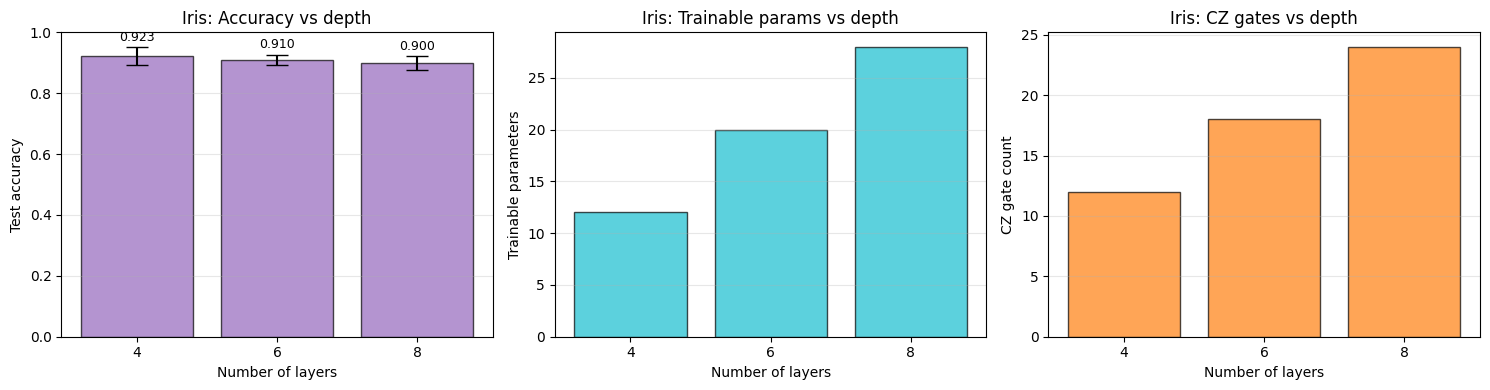

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

layer_vals = [r.config.n_layers for r in results_depth_sweep]
acc_means = [r.summary.test_accuracy_mean for r in results_depth_sweep]
acc_stds = [r.summary.test_accuracy_std for r in results_depth_sweep]
trainable = [r.n_trainable for r in results_depth_sweep]
cz_counts = [r.n_cz_gates for r in results_depth_sweep]

axes[0].bar([str(l) for l in layer_vals], acc_means, yerr=acc_stds,
            capsize=8, color="tab:purple", alpha=0.7, edgecolor="black")
axes[0].set_xlabel("Number of layers")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Iris: Accuracy vs depth")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3, axis="y")
for i, (l, m, s) in enumerate(zip(layer_vals, acc_means, acc_stds)):
    axes[0].text(i, m + s + 0.02, f"{m:.3f}", ha="center", fontsize=9)

axes[1].bar([str(l) for l in layer_vals], trainable,
            color="tab:cyan", alpha=0.7, edgecolor="black")
axes[1].set_xlabel("Number of layers")
axes[1].set_ylabel("Trainable parameters")
axes[1].set_title("Iris: Trainable params vs depth")
axes[1].grid(True, alpha=0.3, axis="y")

axes[2].bar([str(l) for l in layer_vals], cz_counts,
            color="tab:orange", alpha=0.7, edgecolor="black")
axes[2].set_xlabel("Number of layers")
axes[2].set_ylabel("CZ gate count")
axes[2].set_title("Iris: CZ gates vs depth")
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Figure 5: Depth sweep on Iris (4 qubits, linear CZ).** Left: test accuracy vs number of layers — accuracy *decreases monotonically* from L=4 (92.3%) to L=6 (91.0%) to L=8 (90.0%), indicating the inflection point is at or below 4 layers. Centre: trainable parameters (12 → 20 → 28). Right: CZ gates (12 → 18 → 24). More parameters and entanglement do not compensate for the increased optimisation difficulty and noise exposure.

### 6.4 CZ strategy comparison (Iris)

[20] Section 6 identifies CZ-gate configuration as a **significant source of variance** across circuit instances. We compare three strategies at the default Iris configuration (4 qubits, 4 layers):

- **Linear:** Adjacent pairs $(0,1), (1,2), (2,3)$ — deterministic, low-depth overhead.
- **All-to-all:** Every unique pair — maximum entanglement but highest CZ count.
- **Random (3 CZ seeds):** 1–3 randomly chosen pairs per layer — introduces structural variance.

Running three different random CZ seeds lets us quantify how much performance varies purely due to entanglement topology, separate from weight initialisation variance.

In [40]:
cz_configs = cz_sweep_configs(
    strategies=["linear", "all", "random"],
    n_qubits=4,
    n_features=4,
    n_classes=3,
    n_layers=4,
    cz_seeds=[0, 7, 42],
    dataset_name="Iris",
)

results_cz_sweep = run_design_space(
    cz_configs,
    X_iris_tr_qml, y_iris_tr,
    X_iris_te_qml, y_iris_te,
    seeds=SEEDS,
    max_iter=MAX_ITER,
    verbose=True,
    log_interval=LOG_INTERVAL,
)

df_cz = summarize_results(results_cz_sweep)
df_cz


######################################################################
Config 1/5: Iris CZ=linear (Q4_L4_linear)
  Qubits=4, Features=4, Layers=4, CZ=linear
######################################################################

Seed 0 (1/5)
  Eval    1 | loss=0.9498 | train_acc=0.622 | test_acc=0.500 | shots=250
  Eval   25 | loss=0.8212 | train_acc=0.844 | test_acc=0.800 | shots=500
  Eval   50 | loss=0.7645 | train_acc=0.978 | test_acc=0.983 | shots=500
  Eval   75 | loss=0.7448 | train_acc=0.956 | test_acc=0.967 | shots=750
  Eval  100 | loss=0.7372 | train_acc=0.978 | test_acc=0.967 | shots=750

Training complete in 23.4s (100 evaluations)
Best loss: 0.7372
COBYLA status: Maximum number of function evaluations has been exceeded.

Seed 1 (2/5)
  Eval    1 | loss=1.1141 | train_acc=0.456 | test_acc=0.450 | shots=250
  Eval   25 | loss=0.8068 | train_acc=0.778 | test_acc=0.717 | shots=500
  Eval   50 | loss=0.7347 | train_acc=0.967 | test_acc=0.900 | shots=500
  Eval   75 | loss=0.7

,Config,Qubits,Features,Layers,CZ strategy,Depth,Trainable,CZ gates,Total gates,Acc (mean),Acc (std),Acc (min),Acc (max),Train time (s),Infer time (s)
0,Iris CZ=linear,4,4,4,linear,25,12,12,64,0.9233,0.0291,0.8833,0.9667,23.9,0.135
1,Iris CZ=all,4,4,4,all,33,12,24,76,0.8967,0.0323,0.8500,0.9333,26.9,0.151
2,Iris CZ=random (seed=0),4,4,4,random,20,12,7,59,0.8867,0.0125,0.8667,0.9000,22.7,0.125
3,Iris CZ=random (seed=7),4,4,4,random,21,12,10,62,0.7933,0.0583,0.7000,0.8500,23.5,0.132
4,Iris CZ=random (seed=42),4,4,4,random,18,12,5,57,0.8500,0.0350,0.7833,0.8833,22.3,0.123


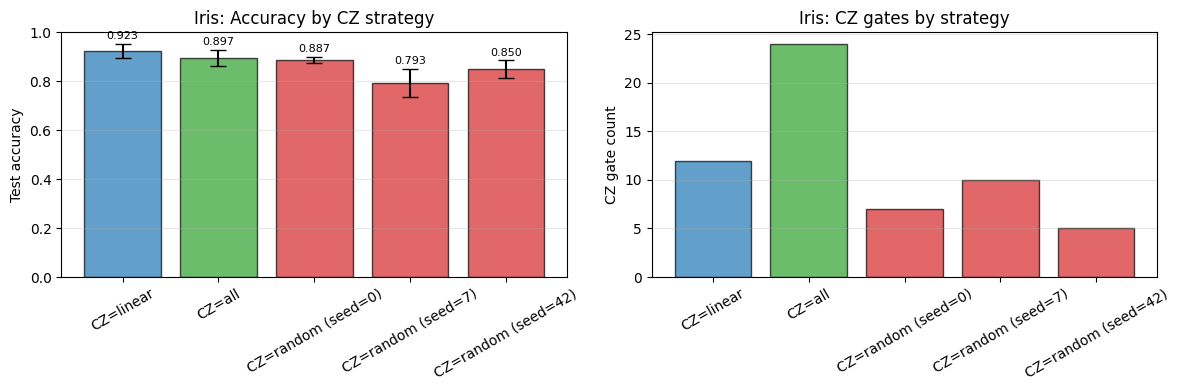

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = [r.config.name.replace("Iris ", "") for r in results_cz_sweep]
acc_means = [r.summary.test_accuracy_mean for r in results_cz_sweep]
acc_stds = [r.summary.test_accuracy_std for r in results_cz_sweep]
cz_counts = [r.n_cz_gates for r in results_cz_sweep]
colors = (["tab:blue", "tab:green"] +
          ["tab:red"] * (len(results_cz_sweep) - 2))

bars = axes[0].bar(labels, acc_means, yerr=acc_stds, capsize=6,
                    color=colors, alpha=0.7, edgecolor="black")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Iris: Accuracy by CZ strategy")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3, axis="y")
axes[0].tick_params(axis="x", rotation=30)
for bar, m, s in zip(bars, acc_means, acc_stds):
    axes[0].text(bar.get_x() + bar.get_width() / 2, m + s + 0.02,
                 f"{m:.3f}", ha="center", fontsize=8)

axes[1].bar(labels, cz_counts, color=colors, alpha=0.7, edgecolor="black")
axes[1].set_ylabel("CZ gate count")
axes[1].set_title("Iris: CZ gates by strategy")
axes[1].grid(True, alpha=0.3, axis="y")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Figure 6: CZ strategy comparison on Iris (4 qubits, 4 layers).** Left: test accuracy (mean $\pm$ std). Linear CZ dominates at 92.3%; all-to-all (89.7%) underperforms despite 2$\times$ more CZ gates; random CZ shows dramatic seed-dependent variance from 79.3% to 88.7%. Right: CZ gate count — random configurations vary from 5 to 10 gates. The 9.4 pp spread across random CZ seeds confirms [20] Section 6's warning about CZ-configuration variance.

### 6.5 Feature count variation (Wine)

Wine has 13 raw features reduced via PCA. [20] uses 8 PCA components; we additionally test 4 components to study the trade-off between information retention and circuit complexity. Fewer features allow fewer qubits (shallower circuits), but discard potentially useful variance.

This experiment directly addresses the **input problem** [1]: how much classical information must be encoded for the quantum circuit to learn meaningfully? And the quantum-specific constraint that qubit budgets force aggressive dimensionality reduction (lecture: "for quantum methods, we need to choose the best features").

In [42]:
X_wine_tr_qml_4, X_wine_te_qml_4, _ = preprocess(
    X_wine_tr, X_wine_te, n_components=4, apply_angle_mapping_flag=True,
)

print(f"Wine PCA 4: {X_wine_tr_qml_4.shape}, Wine PCA 8: {X_wine_tr_qml.shape}")

feature_configs = [
    CircuitConfig(
        name="Wine PCA=4",
        n_qubits=4,
        n_features=4,
        n_classes=3,
        cz_strategy="linear",
    ),
    CircuitConfig(
        name="Wine PCA=8",
        n_qubits=8,
        n_features=8,
        n_classes=3,
        cz_strategy="linear",
    ),
]

results_wine_pca4 = run_design_space(
    [feature_configs[0]],
    X_wine_tr_qml_4, y_wine_tr,
    X_wine_te_qml_4, y_wine_te,
    seeds=SEEDS,
    max_iter=MAX_ITER,
    verbose=True,
    log_interval=LOG_INTERVAL,
)

results_wine_pca8 = run_design_space(
    [feature_configs[1]],
    X_wine_tr_qml, y_wine_tr,
    X_wine_te_qml, y_wine_te,
    seeds=SEEDS,
    max_iter=MAX_ITER,
    verbose=True,
    log_interval=LOG_INTERVAL,
)

results_feature_sweep = results_wine_pca4 + results_wine_pca8
df_feat = summarize_results(results_feature_sweep)
df_feat

Wine PCA 4: (108, 4), Wine PCA 8: (108, 8)

######################################################################
Config 1/1: Wine PCA=4 (Q4_Lauto_linear)
  Qubits=4, Features=4, Layers=auto, CZ=linear
######################################################################

Seed 0 (1/5)
  Eval    1 | loss=1.1481 | train_acc=0.250 | test_acc=0.329 | shots=250
  Eval   25 | loss=0.9827 | train_acc=0.611 | test_acc=0.586 | shots=500
  Eval   50 | loss=0.9256 | train_acc=0.685 | test_acc=0.571 | shots=500
  Eval   75 | loss=0.9168 | train_acc=0.676 | test_acc=0.571 | shots=750
  Eval  100 | loss=0.9164 | train_acc=0.685 | test_acc=0.557 | shots=750

Training complete in 29.3s (100 evaluations)
Best loss: 0.9161
COBYLA status: Maximum number of function evaluations has been exceeded.

Seed 1 (2/5)
  Eval    1 | loss=1.1740 | train_acc=0.278 | test_acc=0.314 | shots=250
  Eval   25 | loss=1.0559 | train_acc=0.426 | test_acc=0.486 | shots=500
  Eval   50 | loss=0.9431 | train_acc=0.667 | test

,Config,Qubits,Features,Layers,CZ strategy,Depth,Trainable,CZ gates,Total gates,Acc (mean),Acc (std),Acc (min),Acc (max),Train time (s),Infer time (s)
0,Wine PCA=4,4,4,4,linear,25,12,12,64,0.5371,0.0623,0.4143,0.5857,28.9,0.153
1,Wine PCA=8,8,8,4,linear,41,24,28,132,0.4714,0.0676,0.3857,0.5429,54.9,0.330


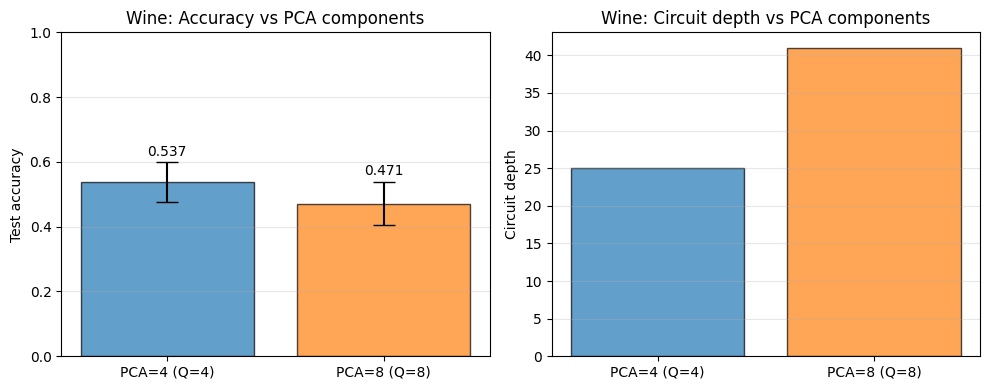

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

labels = ["PCA=4 (Q=4)", "PCA=8 (Q=8)"]
acc_means = [r.summary.test_accuracy_mean for r in results_feature_sweep]
acc_stds = [r.summary.test_accuracy_std for r in results_feature_sweep]
depths = [r.circuit_depth for r in results_feature_sweep]

bars = axes[0].bar(labels, acc_means, yerr=acc_stds, capsize=8,
                    color=["tab:blue", "tab:orange"], alpha=0.7, edgecolor="black")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Wine: Accuracy vs PCA components")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3, axis="y")
for bar, m, s in zip(bars, acc_means, acc_stds):
    axes[0].text(bar.get_x() + bar.get_width() / 2, m + s + 0.02,
                 f"{m:.3f}", ha="center", fontsize=10)

axes[1].bar(labels, depths, color=["tab:blue", "tab:orange"],
            alpha=0.7, edgecolor="black")
axes[1].set_ylabel("Circuit depth")
axes[1].set_title("Wine: Circuit depth vs PCA components")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Figure 7: Feature count comparison on Wine.** Left: test accuracy (mean $\pm$ std) — counterintuitively, PCA=4 (53.7%) outperforms PCA=8 (47.1%), despite retaining less variance. Right: circuit depth — PCA=4 yields a much shallower circuit (depth 25 vs 41). The larger PCA=8 circuit has 2$\times$ the parameters (24 vs 12) and 2.3$\times$ the CZ gates (28 vs 12), but is undertrained at 100 iterations, illustrating the input problem: more features $\neq$ better QML performance when circuit capacity and optimisation budget are fixed.

### 6.6 Qubit count variation (Wine, PCA=8)

The Iris qubit sweep showed that matching qubits to features in a shallow circuit is optimal. Does this hold for a harder 3-class task? We test Q=4, 6, and 8 on Wine with 8 PCA features. When Q < 8, the circuit must use additional layers to encode all features — forcing the same width–depth trade-off seen on Iris but at a larger scale.

| Qubits | Min feature layers | Expected depth | Trade-off |
|--------|-------------------|----------------|-----------|
| 4 | $\lceil 8/4 \rceil = 2$ | Deeper (auto ~6 layers) | Half the qubits, 50% more layers |
| 6 | $\lceil 8/6 \rceil = 2$ | Moderate (auto ~6 layers) | Intermediate |
| 8 | $\lceil 8/8 \rceil = 1$ | Shallow (auto 4 layers) | Matches features — [20] default |

In [44]:
wine_qubit_configs = qubit_sweep_configs(
    qubit_range=[4, 6, 8],
    n_features=8,
    n_classes=3,
    cz_strategy="linear",
    dataset_name="Wine",
)

results_wine_qubit_sweep = run_design_space(
    wine_qubit_configs,
    X_wine_tr_qml, y_wine_tr,
    X_wine_te_qml, y_wine_te,
    seeds=SEEDS,
    max_iter=MAX_ITER,
    verbose=True,
    log_interval=LOG_INTERVAL,
)

df_wine_qubit = summarize_results(results_wine_qubit_sweep)
df_wine_qubit


######################################################################
Config 1/3: Wine Q=4 (Q4_Lauto_linear)
  Qubits=4, Features=8, Layers=auto, CZ=linear
######################################################################

Seed 0 (1/5)
  Eval    1 | loss=1.0871 | train_acc=0.398 | test_acc=0.400 | shots=250
  Eval   25 | loss=1.0026 | train_acc=0.583 | test_acc=0.571 | shots=500
  Eval   50 | loss=0.9558 | train_acc=0.657 | test_acc=0.586 | shots=500
  Eval   75 | loss=0.9477 | train_acc=0.667 | test_acc=0.571 | shots=750
  Eval  100 | loss=0.9462 | train_acc=0.648 | test_acc=0.543 | shots=750

Training complete in 37.9s (100 evaluations)
Best loss: 0.9457
COBYLA status: Maximum number of function evaluations has been exceeded.

Seed 1 (2/5)
  Eval    1 | loss=1.1793 | train_acc=0.259 | test_acc=0.300 | shots=250
  Eval   25 | loss=1.0210 | train_acc=0.481 | test_acc=0.557 | shots=500
  Eval   50 | loss=0.9790 | train_acc=0.556 | test_acc=0.514 | shots=500
  Eval   75 | loss=0.9

,Config,Qubits,Features,Layers,CZ strategy,Depth,Trainable,CZ gates,Total gates,Acc (mean),Acc (std),Acc (min),Acc (max),Train time (s),Infer time (s)
0,Wine Q=4,4,8,6,linear,37,16,18,94,0.5343,0.0333,0.4714,0.5714,37.2,0.216
1,Wine Q=6,6,8,6,linear,49,28,30,144,0.5429,0.0221,0.5000,0.5571,52.8,0.329
2,Wine Q=8,8,8,4,linear,41,24,28,132,0.4714,0.0676,0.3857,0.5429,54.9,0.314


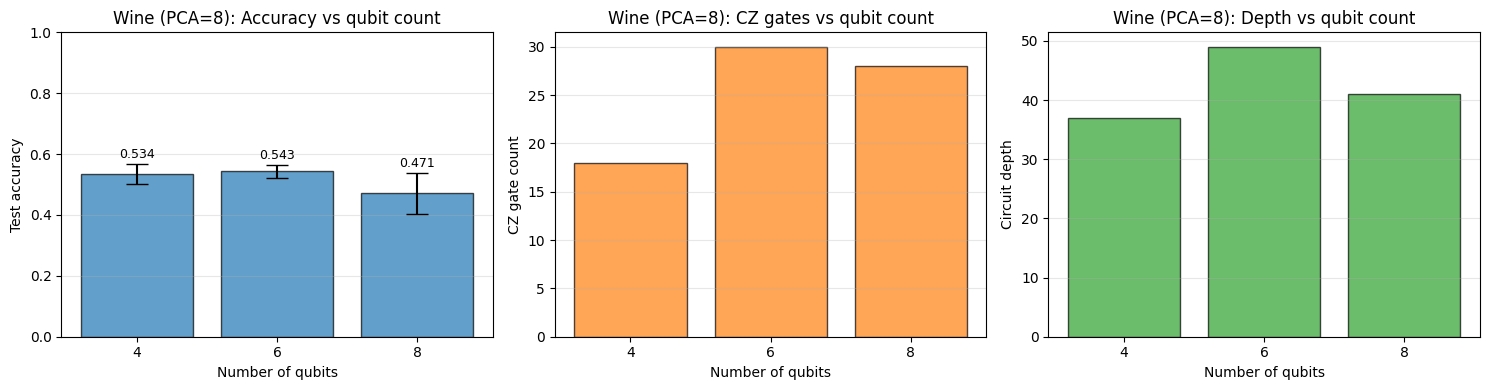

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

qubit_vals = [r.config.n_qubits for r in results_wine_qubit_sweep]
acc_means = [r.summary.test_accuracy_mean for r in results_wine_qubit_sweep]
acc_stds = [r.summary.test_accuracy_std for r in results_wine_qubit_sweep]
cz_counts = [r.n_cz_gates for r in results_wine_qubit_sweep]
depths = [r.circuit_depth for r in results_wine_qubit_sweep]

axes[0].bar([str(q) for q in qubit_vals], acc_means, yerr=acc_stds,
            capsize=8, color="tab:blue", alpha=0.7, edgecolor="black")
axes[0].set_xlabel("Number of qubits")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Wine (PCA=8): Accuracy vs qubit count")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3, axis="y")
for i, (q, m, s) in enumerate(zip(qubit_vals, acc_means, acc_stds)):
    axes[0].text(i, m + s + 0.02, f"{m:.3f}", ha="center", fontsize=9)

axes[1].bar([str(q) for q in qubit_vals], cz_counts,
            color="tab:orange", alpha=0.7, edgecolor="black")
axes[1].set_xlabel("Number of qubits")
axes[1].set_ylabel("CZ gate count")
axes[1].set_title("Wine (PCA=8): CZ gates vs qubit count")
axes[1].grid(True, alpha=0.3, axis="y")

axes[2].bar([str(q) for q in qubit_vals], depths,
            color="tab:green", alpha=0.7, edgecolor="black")
axes[2].set_xlabel("Number of qubits")
axes[2].set_ylabel("Circuit depth")
axes[2].set_title("Wine (PCA=8): Depth vs qubit count")
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Figure 9: Qubit count sweep on Wine (PCA=8).** Left: test accuracy (mean $\pm$ std across 5 seeds) — Q=6 (54.3%) is best, Q=4 (53.4%) second, Q=8 (47.1%) worst. The Iris "match qubits to features" finding does *not* generalise: the 4-layer Q=8 circuit underperforms. Centre: CZ gate count. Right: circuit depth. The narrower circuits (Q=4, Q=6) use 6 auto-selected layers; Q=8 uses 4.

### 6.7 Depth variation (Wine, PCA=4, Q=4)

Using the smaller PCA=4/Q=4 Wine configuration (which outperformed PCA=8 in Section 6.5), we test whether the depth trend from Iris holds: does adding layers help or hurt? We compare L=4 (the default from Section 6.5) with L=6 to check for the inflection point on a harder task.

In [46]:
wine_depth_configs = depth_sweep_configs(
    layer_range=[4, 6],
    n_qubits=4,
    n_features=4,
    n_classes=3,
    cz_strategy="linear",
    dataset_name="Wine (PCA=4)",
)

results_wine_depth_sweep = run_design_space(
    wine_depth_configs,
    X_wine_tr_qml_4, y_wine_tr,
    X_wine_te_qml_4, y_wine_te,
    seeds=SEEDS,
    max_iter=MAX_ITER,
    verbose=True,
    log_interval=LOG_INTERVAL,
)

df_wine_depth = summarize_results(results_wine_depth_sweep)
df_wine_depth


######################################################################
Config 1/2: Wine (PCA=4) L=4 (Q4_L4_linear)
  Qubits=4, Features=4, Layers=4, CZ=linear
######################################################################

Seed 0 (1/5)
  Eval    1 | loss=1.1481 | train_acc=0.250 | test_acc=0.329 | shots=250
  Eval   25 | loss=0.9827 | train_acc=0.611 | test_acc=0.586 | shots=500
  Eval   50 | loss=0.9256 | train_acc=0.685 | test_acc=0.571 | shots=500
  Eval   75 | loss=0.9168 | train_acc=0.676 | test_acc=0.571 | shots=750
  Eval  100 | loss=0.9164 | train_acc=0.685 | test_acc=0.557 | shots=750

Training complete in 29.3s (100 evaluations)
Best loss: 0.9161
COBYLA status: Maximum number of function evaluations has been exceeded.

Seed 1 (2/5)
  Eval    1 | loss=1.1740 | train_acc=0.278 | test_acc=0.314 | shots=250
  Eval   25 | loss=1.0559 | train_acc=0.426 | test_acc=0.486 | shots=500
  Eval   50 | loss=0.9431 | train_acc=0.667 | test_acc=0.571 | shots=500
  Eval   75 | loss=0

,Config,Qubits,Features,Layers,CZ strategy,Depth,Trainable,CZ gates,Total gates,Acc (mean),Acc (std),Acc (min),Acc (max),Train time (s),Infer time (s)
0,Wine (PCA=4) L=4,4,4,4,linear,25,12,12,64,0.5371,0.0623,0.4143,0.5857,29.0,0.164
1,Wine (PCA=4) L=6,4,4,6,linear,37,20,18,94,0.5943,0.0466,0.5429,0.6571,37.2,0.238


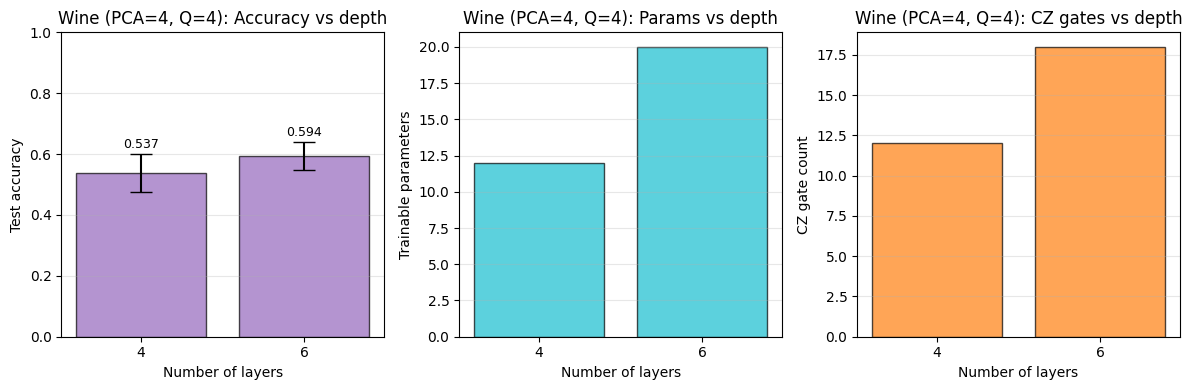

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

layer_vals = [r.config.n_layers for r in results_wine_depth_sweep]
acc_means = [r.summary.test_accuracy_mean for r in results_wine_depth_sweep]
acc_stds = [r.summary.test_accuracy_std for r in results_wine_depth_sweep]
trainable = [r.n_trainable for r in results_wine_depth_sweep]
cz_counts = [r.n_cz_gates for r in results_wine_depth_sweep]

axes[0].bar([str(l) for l in layer_vals], acc_means, yerr=acc_stds,
            capsize=8, color="tab:purple", alpha=0.7, edgecolor="black")
axes[0].set_xlabel("Number of layers")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Wine (PCA=4, Q=4): Accuracy vs depth")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3, axis="y")
for i, (l, m, s) in enumerate(zip(layer_vals, acc_means, acc_stds)):
    axes[0].text(i, m + s + 0.02, f"{m:.3f}", ha="center", fontsize=9)

axes[1].bar([str(l) for l in layer_vals], trainable,
            color="tab:cyan", alpha=0.7, edgecolor="black")
axes[1].set_xlabel("Number of layers")
axes[1].set_ylabel("Trainable parameters")
axes[1].set_title("Wine (PCA=4, Q=4): Params vs depth")
axes[1].grid(True, alpha=0.3, axis="y")

axes[2].bar([str(l) for l in layer_vals], cz_counts,
            color="tab:orange", alpha=0.7, edgecolor="black")
axes[2].set_xlabel("Number of layers")
axes[2].set_ylabel("CZ gate count")
axes[2].set_title("Wine (PCA=4, Q=4): CZ gates vs depth")
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Figure 10: Depth sweep on Wine (PCA=4, Q=4, linear CZ).** L=6 (59.4%) *outperforms* L=4 (53.7%) by ~6 pp — the opposite of Iris, where adding depth hurt. For this harder 3-class task, more depth helps within the 100-iteration budget. L=4 has 12 trainable parameters and 12 CZ gates; L=6 has 20 parameters and 18 CZ gates.

### 6.8 Feature count variation (Breast Cancer)

Breast Cancer is the most challenging dataset: 30 raw features and a binary classification task. The default PCA=12/Q=12 configuration from Section 5 is expensive (~855s/seed) and produces poor accuracy (62.8%). We test a **PCA=8/Q=8** alternative — a substantially smaller circuit that trades information retention for trainability and hardware friendliness.

This parallels the Wine feature-count experiment (Section 6.5), testing whether aggressive dimensionality reduction helps or hurts on a binary task. The PCA=8 configuration retains less of the original 30-feature variance but yields a circuit with fewer CZ gates, lower depth, and a smaller optimisation landscape.

In [48]:
X_bc_tr_qml_8, X_bc_te_qml_8, _ = preprocess(
    X_bc_tr, X_bc_te, n_components=8, apply_angle_mapping_flag=True,
)

print(f"BC PCA 8: {X_bc_tr_qml_8.shape}, BC PCA 12: {X_bc_tr_qml.shape}")

bc_feature_configs = [
    CircuitConfig(
        name="BC PCA=8",
        n_qubits=8,
        n_features=8,
        n_classes=2,
        cz_strategy="linear",
    ),
]

results_bc_pca8 = run_design_space(
    bc_feature_configs,
    X_bc_tr_qml_8, y_bc_tr,
    X_bc_te_qml_8, y_bc_te,
    seeds=SEEDS,
    max_iter=MAX_ITER,
    verbose=True,
    log_interval=LOG_INTERVAL,
)

BC PCA 8: (449, 8), BC PCA 12: (449, 12)

######################################################################
Config 1/1: BC PCA=8 (Q8_Lauto_linear)
  Qubits=8, Features=8, Layers=auto, CZ=linear
######################################################################

Seed 0 (1/5)
  Eval    1 | loss=0.6584 | train_acc=0.639 | test_acc=0.617 | shots=250
  Eval   25 | loss=0.6520 | train_acc=0.646 | test_acc=0.592 | shots=500
  Eval   50 | loss=0.6316 | train_acc=0.653 | test_acc=0.633 | shots=500
  Eval   75 | loss=0.6270 | train_acc=0.659 | test_acc=0.625 | shots=750
  Eval  100 | loss=0.6220 | train_acc=0.668 | test_acc=0.675 | shots=750

Training complete in 221.2s (100 evaluations)
Best loss: 0.6215
COBYLA status: Maximum number of function evaluations has been exceeded.

Seed 1 (2/5)
  Eval    1 | loss=0.6735 | train_acc=0.610 | test_acc=0.600 | shots=250
  Eval   25 | loss=0.6685 | train_acc=0.617 | test_acc=0.583 | shots=500
  Eval   50 | loss=0.6570 | train_acc=0.633 | test_ac

In [55]:
bc_pca12_ref = CircuitConfig(
    name="BC PCA=12", n_qubits=12, n_features=12, n_classes=2, cz_strategy="linear",
)
vc_bc12 = bc_pca12_ref.build()
ops_bc12 = vc_bc12.circuit.count_ops()
ops_by_name = {getattr(k, "name", str(k)): v for k, v in ops_bc12.items()}

from qml_project.design_space import DesignSpaceResult

results_bc_pca12_ref = DesignSpaceResult(
    config=bc_pca12_ref,
    summary=results_bc_qml,
    circuit_depth=vc_bc12.circuit.depth(),
    n_trainable=vc_bc12.n_trainable,
    n_cz_gates=ops_by_name.get("cz", 0),
    n_total_gates=sum(v for k, v in ops_by_name.items() if k != "barrier"),
    n_layers_actual=vc_bc12.n_layers,
)

results_bc_feature_sweep = results_bc_pca8 + [results_bc_pca12_ref]

df_bc_feat = summarize_results(results_bc_feature_sweep)
df_bc_feat

,Config,Qubits,Features,Layers,CZ strategy,Depth,Trainable,CZ gates,Total gates,Acc (mean),Acc (std),Acc (min),Acc (max),Train time (s),Infer time (s)
0,BC PCA=8,8,8,4,linear,41,24,28,132,0.6467,0.0251,0.6000,0.675,220.6,0.527
1,BC PCA=12,12,12,4,linear,57,36,44,200,0.6283,0.0125,0.6167,0.650,854.9,2.154


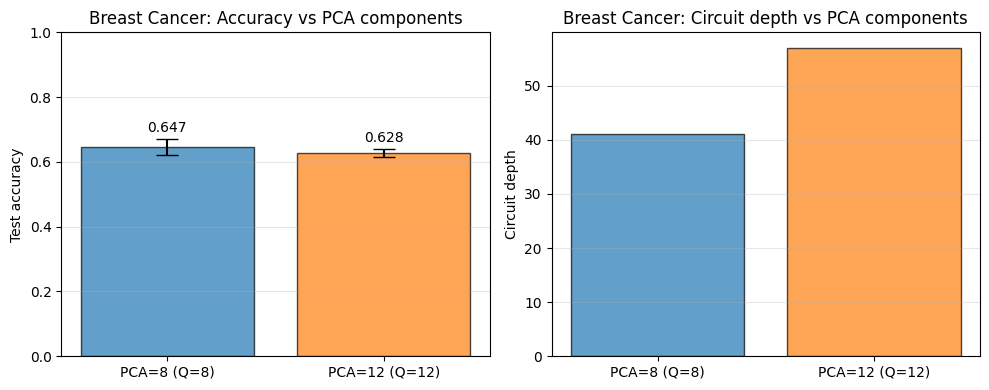

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

labels = ["PCA=8 (Q=8)", "PCA=12 (Q=12)"]
acc_means = [r.summary.test_accuracy_mean for r in results_bc_feature_sweep]
acc_stds = [r.summary.test_accuracy_std for r in results_bc_feature_sweep]
depths = [r.circuit_depth for r in results_bc_feature_sweep]

bars = axes[0].bar(labels, acc_means, yerr=acc_stds, capsize=8,
                    color=["tab:blue", "tab:orange"], alpha=0.7, edgecolor="black")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Breast Cancer: Accuracy vs PCA components")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3, axis="y")
for bar, m, s in zip(bars, acc_means, acc_stds):
    axes[0].text(bar.get_x() + bar.get_width() / 2, m + s + 0.02,
                 f"{m:.3f}", ha="center", fontsize=10)

axes[1].bar(labels, depths, color=["tab:blue", "tab:orange"],
            alpha=0.7, edgecolor="black")
axes[1].set_ylabel("Circuit depth")
axes[1].set_title("Breast Cancer: Circuit depth vs PCA components")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Figure 11: Feature count comparison on Breast Cancer.** Left: PCA=8 (64.7% $\pm$ 2.5%) *outperforms* PCA=12 (62.8% $\pm$ 1.3%) by ~2 pp, confirming the Wine feature-count trend. Right: circuit depth (41 vs 57). PCA=8 also trains ~4$\times$ faster (221 s vs 855 s per config) and has fewer CZ gates (28 vs 44), making it the preferred choice for device inference.

### 6.9 Combined design-space summary

The table below combines all design-space experiments — Iris, Wine, and Breast Cancer — into a single view, sorted by accuracy. This enables direct cross-dataset comparison across all varied dimensions (qubit count, depth, CZ strategy, feature count).

In [51]:
all_design_results = (
    results_qubit_sweep
    + results_depth_sweep
    + results_cz_sweep
    + results_feature_sweep
    + results_wine_qubit_sweep
    + results_wine_depth_sweep
    + results_bc_pca8
    + [results_bc_pca12_ref]
)

df_all = summarize_results(all_design_results)
df_all.sort_values("Acc (mean)", ascending=False).reset_index(drop=True)

,Config,Qubits,Features,Layers,CZ strategy,Depth,Trainable,CZ gates,Total gates,Acc (mean),Acc (std),Acc (min),Acc (max),Train time (s),Infer time (s)
0,Iris L=4,4,4,4,linear,25,12,12,64,0.9233,0.0291,0.8833,0.9667,24.1,0.138
1,Iris Q=4,4,4,4,linear,25,12,12,64,0.9233,0.0291,0.8833,0.9667,24.1,0.134
2,Iris CZ=linear,4,4,4,linear,25,12,12,64,0.9233,0.0291,0.8833,0.9667,23.9,0.135
3,Iris L=6,4,4,6,linear,37,20,18,94,0.9100,0.0170,0.8833,0.9333,31.1,0.180
4,Iris L=8,4,4,8,linear,49,28,24,124,0.9000,0.0236,0.8667,0.9333,39.2,0.239
5,Iris CZ=all,4,4,4,all,33,12,24,76,0.8967,0.0323,0.8500,0.9333,26.9,0.151
6,Iris CZ=random (seed=0),4,4,4,random,20,12,7,59,0.8867,0.0125,0.8667,0.9000,22.7,0.125
7,Iris CZ=random (seed=42),4,4,4,random,18,12,5,57,0.8500,0.0350,0.7833,0.8833,22.3,0.123
8,Iris Q=2,2,4,6,linear,25,8,6,44,0.8433,0.0416,0.7667,0.8833,19.9,0.110
9,Iris Q=3,3,4,6,linear,31,14,12,69,0.8333,0.0408,0.7667,0.8833,25.2,0.145


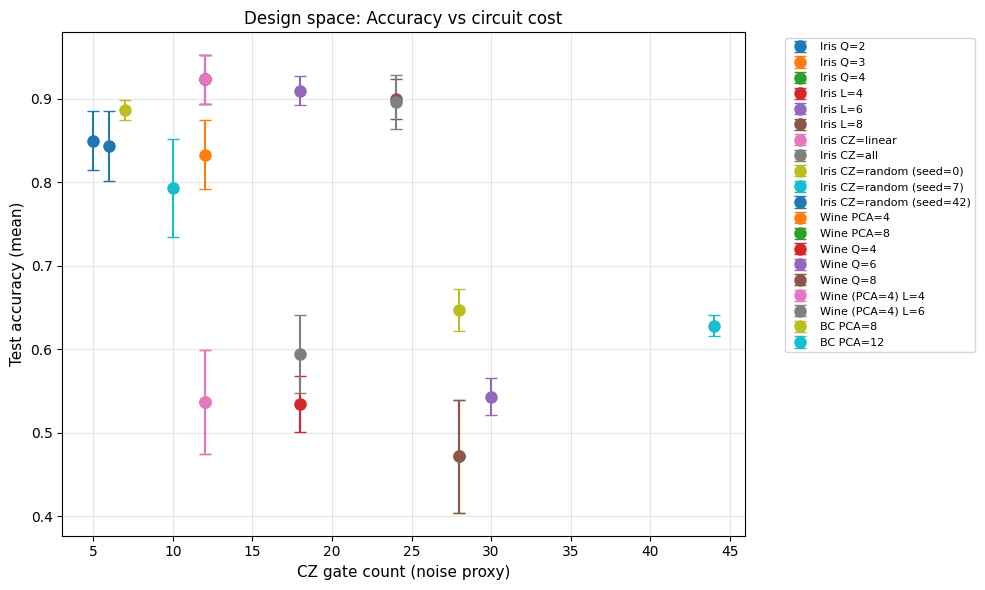

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))

for r in all_design_results:
    ax.errorbar(
        r.n_cz_gates,
        r.summary.test_accuracy_mean,
        yerr=r.summary.test_accuracy_std,
        fmt="o",
        markersize=8,
        capsize=4,
        label=r.config.name,
    )

ax.set_xlabel("CZ gate count (noise proxy)", fontsize=11)
ax.set_ylabel("Test accuracy (mean)", fontsize=11)
ax.set_title("Design space: Accuracy vs circuit cost", fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 12: Design-space overview (all datasets).** Each point represents one configuration; $x$-axis is CZ gate count (proxy for noise exposure), $y$-axis is mean test accuracy. The three datasets form distinct clusters: Iris configs occupy the top (80–92%), Wine and BC configs cluster at the bottom (40–60%). Within each cluster, the negative trend (more CZ $\rightarrow$ lower or equal accuracy) confirms that CZ gates are the dominant cost factor.

### 6.10 Circuit selection for device inference

For real-device inference (Phase 3), we need circuits that balance:

1. **Accuracy** — high enough to produce a meaningful comparison with classical baselines.
2. **Hardware friendliness** — shallow depth, few CZ gates, and small qubit count to minimise noise degradation and queue time on free-tier backends.
3. **Dataset coverage** — at least one circuit per dataset for the three-way comparison.

We apply conservative hardware constraints (depth $\leq 50$, CZ gates $\leq 30$) and select the top configurations. For Breast Cancer, we now have a PCA=8/Q=8 alternative that may fit within these constraints.

In [53]:
device_candidates = select_device_circuits(
    all_design_results,
    max_depth=50,
    max_cz=30,
    min_accuracy=0.3,
    top_k=5,
)

print("=== Top device-friendly configurations ===\n")
for i, r in enumerate(device_candidates, 1):
    print(
        f"  {i}. {r.config.name:<25s} "
        f"Acc={r.summary.test_accuracy_mean:.3f} ± {r.summary.test_accuracy_std:.3f}  "
        f"Depth={r.circuit_depth}  CZ={r.n_cz_gates}  Q={r.config.n_qubits}"
    )

df_device = summarize_results(device_candidates)
df_device

=== Top device-friendly configurations ===

  1. Iris Q=4                  Acc=0.923 ± 0.029  Depth=25  CZ=12  Q=4
  2. Iris L=4                  Acc=0.923 ± 0.029  Depth=25  CZ=12  Q=4
  3. Iris CZ=linear            Acc=0.923 ± 0.029  Depth=25  CZ=12  Q=4
  4. Iris L=6                  Acc=0.910 ± 0.017  Depth=37  CZ=18  Q=4
  5. Iris L=8                  Acc=0.900 ± 0.024  Depth=49  CZ=24  Q=4


,Config,Qubits,Features,Layers,CZ strategy,Depth,Trainable,CZ gates,Total gates,Acc (mean),Acc (std),Acc (min),Acc (max),Train time (s),Infer time (s)
0,Iris Q=4,4,4,4,linear,25,12,12,64,0.9233,0.0291,0.8833,0.9667,24.1,0.134
1,Iris L=4,4,4,4,linear,25,12,12,64,0.9233,0.0291,0.8833,0.9667,24.1,0.138
2,Iris CZ=linear,4,4,4,linear,25,12,12,64,0.9233,0.0291,0.8833,0.9667,23.9,0.135
3,Iris L=6,4,4,6,linear,37,20,18,94,0.9100,0.0170,0.8833,0.9333,31.1,0.180
4,Iris L=8,4,4,8,linear,49,28,24,124,0.9000,0.0236,0.8667,0.9333,39.2,0.239


### 6.11 Device inference plan

Based on the comprehensive design-space exploration across all three datasets, we select the following circuits for real-device inference:

| Dataset | Config | Qubits | Layers | CZ | Rationale |
|---------|--------|--------|--------|-----|-----------|
| **Iris** | Q=4, L=4, linear | 4 | 4 | 12 | Best accuracy (92.3%), shallow, lowest noise risk |
| **Wine** | PCA=4, Q=4, **L=6**, linear | 4 | 6 | 18 | Depth sweep (Section 6.7): L=6 (59.4%) beats L=4 (53.7%); best Wine config |
| **Breast Cancer** | PCA=8, Q=8, linear | 8 | 4 | 28 | **Preferred:** 64.7% vs PCA=12's 62.8%; 28 CZ, ~4$\times$ faster to train |
| **Breast Cancer** | PCA=12, Q=12, linear | 12 | 4 | 44 | For comparison: device-vs-sim degradation vs PCA=8 |

**Iris** is the primary device-inference candidate: 4 qubits, 12 CZ gates, and 92.3% mean simulated accuracy (best seed 96.7%).

**Wine** uses **PCA=4, Q=4, L=6** (not L=4). The depth sweep (Section 6.7) showed that on this harder 3-class task, L=6 (59.4% $\pm$ 4.7%) outperforms L=4 (53.7% $\pm$ 6.2%) by ~6 pp — the opposite of Iris, where minimal depth was optimal. The 4-qubit, 6-layer circuit remains hardware-friendly (18 CZ gates).

**Breast Cancer:** PCA=8/Q=8 (64.7% mean, 28 CZ) is the primary device circuit: it outperforms PCA=12 (62.8%) and trains ~4$\times$ faster. PCA=12/Q=12 (44 CZ) is included to compare device-vs-simulation degradation by circuit size — a concrete test of the **costing problem** [1].

For each selected circuit, we use the **best weights from simulation** (the seed with highest test accuracy) for device inference (no training on the device).

### 6.12 Design-space discussion

#### Width–depth trade-off: task-dependent, not universal

The qubit and depth sweeps show that [20]'s "shallow and wide" recommendation holds on Iris but **does not generalise** to Wine:

**Iris (Sections 6.2–6.3):**
- **Qubit sweep:** Q=4 (92.3%) dramatically outperforms Q=2 (84.3%) and Q=3 (83.3%). Q=4 receives an *auto-assigned* 4-layer circuit (shallow) while Q=2 and Q=3 require 6 layers (deeper) to encode all 4 features. The width and depth advantages compound.
- **Depth sweep:** At fixed Q=4, accuracy *decreases monotonically* with depth: L=4 (92.3%) > L=6 (91.0%) > L=8 (90.0%). The L=4 configuration is at or past the **inflection point** identified by [20] Section 6.

**Wine (Sections 6.6–6.7) — opposite trends:**
- **Qubit sweep (PCA=8):** Q=8 (47.1%) is *worst*; Q=6 (54.3%) is best, Q=4 (53.4%) second. The "match qubits to features" guideline from Iris fails: the 4-layer, 8-qubit circuit underperforms narrower circuits that use 6 auto-selected layers. The 100-iteration budget may be insufficient for the larger Q=8 parameter space.
- **Depth sweep (PCA=4, Q=4):** L=6 (59.4%) *outperforms* L=4 (53.7%) by ~6 pp. For this harder 3-class task, adding depth helps — the opposite of Iris. The depth inflection is thus **task-dependent**: minimal depth is optimal for the easy Iris task; for Wine, one extra block (L=6) improves accuracy before barren-plateau or noise effects dominate.

**Practical implication:** For easy, small-feature tasks (Iris), minimal depth suffices. For harder tasks (Wine), a modest increase in depth (L=6) can improve accuracy; the device plan therefore uses Wine L=6.

#### CZ configuration: confirmed as a major variance source

The CZ sweep on Iris (Section 6.4) reveals that entanglement topology is one of the largest sources of variability:

- **Linear CZ** achieves the best mean accuracy: $92.3\% \pm 2.9\%$ with 12 CZ gates.
- **All-to-all CZ** underperforms despite double the CZ gates (24): $89.7\% \pm 3.2\%$. The additional entanglement does not help and may hurt by increasing the effective noise exposure.
- **Random CZ** exhibits dramatic seed-to-seed variation: accuracies range from $79.3\%$ (seed=7, 10 CZ gates) to $88.7\%$ (seed=0, 7 CZ gates) — a 9.4 pp spread. This spread is larger than the weight-initialisation variance within any single CZ configuration (which ranges from 1.3 to 5.8 pp std).

This confirms [20] Section 6's claim that CZ configuration is a "significant source of variance." Linear CZ — a deterministic, structured pattern — outperforms because it avoids the risk of pathological random topologies. For practitioners, **CZ strategy should be treated as a hyperparameter**, and results with a single random CZ configuration are unreliable.

#### Barren plateaus and trainability

The Iris depth sweep shows symptoms consistent with barren-plateau effects (McClean et al., cited by [20]):

- The 8-layer circuit (28 trainable parameters) converges more slowly, with several seeds showing loss values above 0.74 at evaluation 100 compared to 0.73 for the 4-layer circuit.
- Despite having 2.3$\times$ more trainable parameters, the 8-layer version achieves *lower* accuracy (90.0% vs 92.3%), consistent with gradient vanishing in deeper circuits.
- Training time scales linearly with depth (24s → 31s → 38s), making deeper circuits both slower and worse.

A systematic gradient-magnitude analysis is beyond our scope, but these observations support [20]'s call for shallow circuits as a practical mitigation of barren plateaus.

#### Feature count and the input problem: consistent across Wine and BC

The feature-count experiments on Wine (Section 6.5) and Breast Cancer (Section 6.8) both show that **fewer PCA components can yield better QML accuracy** when the resulting circuit is more trainable:

**Wine:** PCA=4 ($53.7\% \pm 6.2\%$) outperforms PCA=8 ($47.1\% \pm 6.8\%$) — fewer features, better accuracy.

**Breast Cancer:** PCA=8 ($64.7\% \pm 2.5\%$) outperforms PCA=12 ($62.8\% \pm 1.3\%$) by ~2 pp. PCA=8 also has 28 CZ gates (vs 44), depth 41 (vs 57), and trains ~4$\times$ faster (221 s vs 855 s per config). The [20] circuit architecture is **capacity-limited**: increasing the input dimension without proportionally increasing the optimisation budget yields diminishing or negative returns.

This pattern illustrates the **input problem** [1]: encoding more classical information is not free. The qubit budget forces PCA compression; the *optimisation* budget is equally constraining. With a fixed 100-iteration COBYLA budget, larger circuits are undertrained.

#### Cross-dataset generalisability: actual outcomes

| Finding | Iris | Wine | BC | Generalises? |
|---------|------|------|----|-------------|
| Shallow-wide optimal | Yes (Q=4, L=4 best) | **No** (Q=8 worst; L=6 > L=4) | — | **Task-dependent** |
| Linear CZ best | Yes (92.3% vs 79–90% random) | — | — | Tested on Iris only |
| Fewer features can help | — | Yes (PCA=4 > PCA=8) | Yes (PCA=8 > PCA=12) | **Yes** |
| Depth hurts at fixed Q | Yes (L=4 > L=6 > L=8) | **No** (L=6 > L=4) | — | **Task-dependent** |

The Wine and BC results show that Iris findings are **not universal**. Depth and qubit-scaling behaviour depend on task difficulty and feature count; the feature-count effect (fewer PCA components helping) is the one that generalises across Wine and BC.

#### Implications for [20] replication

Our design-space exploration extends [20]'s analysis in several concrete ways:

- **Width–depth inflection is task-dependent:** On Iris (4 features), the inflection is at or below 4 layers. On Wine (PCA=4, 4 features but harder 3-class task), L=6 beats L=4. [20]'s shallow-wide recommendation holds for the easiest task but not for harder ones within the same iteration budget.
- **Qubit scaling does not generalise:** On Iris, Q=4 (match features) is best. On Wine PCA=8, Q=8 (match features) is *worst* (47.1%); Q=6 (54.3%) and Q=4 (53.4%) are better. The 8-qubit circuit is undertrained; "more qubits" is not better when the optimiser cannot scale.
- **CZ variance quantified:** The 9.4 pp spread across random CZ seeds (Iris) confirms [20]'s concern; linear CZ is the safe choice.
- **Feature–qubit coupling:** Wine and BC both show that retaining *fewer* PCA components can improve accuracy (PCA=4 > PCA=8, PCA=8 > PCA=12) — a practical constraint [20] does not systematically explore.

These findings directly inform the device-inference plan (Section 6.11): we use Iris L=4, Wine L=6, and BC PCA=8 as the primary device circuits, and revisit the comparison in Phase 3.

In [56]:
best_seed_iris = max(results_iris_qml.per_seed, key=lambda r: r.test_accuracy)
# Wine L=6 (best Wine config from depth sweep, Section 6.7)
best_seed_wine_l6 = max(results_wine_depth_sweep[1].summary.per_seed, key=lambda r: r.test_accuracy)
best_seed_bc_pca8 = max(results_bc_pca8[0].summary.per_seed, key=lambda r: r.test_accuracy)
best_seed_bc_pca12 = max(results_bc_qml.per_seed, key=lambda r: r.test_accuracy)

device_circuits = {
    "Iris": {
        "config": {"n_qubits": 4, "n_features": 4, "n_classes": 3, "cz_strategy": "linear", "n_layers": 4},
        "best_seed": best_seed_iris.seed,
        "best_weights": best_seed_iris.best_weights,
        "sim_accuracy": best_seed_iris.test_accuracy,
    },
    "Wine (PCA=4, L=6)": {
        "config": {"n_qubits": 4, "n_features": 4, "n_classes": 3, "cz_strategy": "linear", "n_layers": 6},
        "best_seed": best_seed_wine_l6.seed,
        "best_weights": best_seed_wine_l6.best_weights,
        "sim_accuracy": best_seed_wine_l6.test_accuracy,
    },
    "Breast Cancer (PCA=8)": {
        "config": {"n_qubits": 8, "n_features": 8, "n_classes": 2, "cz_strategy": "linear"},
        "best_seed": best_seed_bc_pca8.seed,
        "best_weights": best_seed_bc_pca8.best_weights,
        "sim_accuracy": best_seed_bc_pca8.test_accuracy,
    },
    "Breast Cancer (PCA=12)": {
        "config": {"n_qubits": 12, "n_features": 12, "n_classes": 2, "cz_strategy": "linear"},
        "best_seed": best_seed_bc_pca12.seed,
        "best_weights": best_seed_bc_pca12.best_weights,
        "sim_accuracy": best_seed_bc_pca12.test_accuracy,
    },
}

print("Device inference circuits (best seed per dataset):\n")
for name, info in device_circuits.items():
    print(f"  {name}: seed={info['best_seed']}, "
          f"sim_acc={info['sim_accuracy']:.4f}, "
          f"n_weights={len(info['best_weights'])}")

Device inference circuits (best seed per dataset):

  Iris: seed=0, sim_acc=0.9667, n_weights=12
  Wine (PCA=4, L=6): seed=0, sim_acc=0.6571, n_weights=20
  Breast Cancer (PCA=8): seed=0, sim_acc=0.6750, n_weights=24
  Breast Cancer (PCA=12): seed=0, sim_acc=0.6500, n_weights=36
